In [1]:
# =========================
# NUMERICAL COMPUTING
# =========================
import numpy as np
import pandas as pd

# =========================
# DATA VISUALIZATION
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# SCIKIT-LEARN UTILITIES
# =========================
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# =========================
# DATA PREPROCESSING
# =========================
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    LabelEncoder,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# =========================
# FEATURE SELECTION
# =========================
from sklearn.feature_selection import (
    SelectKBest,
    chi2,
    f_classif,
    mutual_info_classif
)

# =========================
# CLASSIFICATION MODELS
# =========================
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

from sklearn.naive_bayes import (
    GaussianNB,
    MultinomialNB
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

# =========================
# REGRESSION MODELS
# =========================
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    ExtraTreesRegressor
)

from sklearn.svm import SVR

from sklearn.neighbors import KNeighborsRegressor

# =========================
# CLUSTERING
# =========================
from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering
)

# =========================
# DIMENSIONALITY REDUCTION
# =========================
from sklearn.decomposition import PCA

# =========================
# ENSEMBLE LEARNING
# =========================
from sklearn.ensemble import (
    VotingClassifier,
    VotingRegressor,
    BaggingClassifier,
    BaggingRegressor,
    StackingClassifier,
    StackingRegressor
)

# =========================
# BOOSTING LIBRARIES
# =========================
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

# =========================
# WARNINGS
# =========================
import warnings
warnings.filterwarnings("ignore")

In [2]:
df_bureau = pd.read_csv('bureau_data.csv')
df_customers = pd.read_csv('customers.csv')
df_loans = pd.read_csv('loans.csv')

## BUREAU

In [3]:
df_bureau

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7
1,C00002,3,1,96,12,60,5,4
2,C00003,2,1,82,24,147,6,58
3,C00004,3,0,115,15,87,5,26
4,C00005,4,2,120,0,0,5,10
...,...,...,...,...,...,...,...,...
49995,C49996,4,2,165,1,6,8,24
49996,C49997,4,0,161,0,0,4,91
49997,C49998,4,1,42,0,0,7,38
49998,C49999,1,2,42,9,47,4,17


In [4]:
df_bureau.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   cust_id                    50000 non-null  object
 1   number_of_open_accounts    50000 non-null  int64 
 2   number_of_closed_accounts  50000 non-null  int64 
 3   total_loan_months          50000 non-null  int64 
 4   delinquent_months          50000 non-null  int64 
 5   total_dpd                  50000 non-null  int64 
 6   enquiry_count              50000 non-null  int64 
 7   credit_utilization_ratio   50000 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 3.1+ MB


In [5]:
df_bureau.isna().sum()

cust_id                      0
number_of_open_accounts      0
number_of_closed_accounts    0
total_loan_months            0
delinquent_months            0
total_dpd                    0
enquiry_count                0
credit_utilization_ratio     0
dtype: int64

In [6]:
df_bureau.describe()

,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
count,50000.000000,50000.00000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000
mean,2.500140,1.00106,76.127140,4.87890,26.858000,5.009340,43.36142
std,1.118725,0.81412,43.762469,5.85032,32.832832,2.029122,29.35598
min,1.000000,0.00000,1.000000,0.00000,0.000000,1.000000,0.00000
25%,1.000000,0.00000,42.000000,0.00000,0.000000,4.000000,18.00000
50%,3.000000,1.00000,71.000000,3.00000,14.000000,5.000000,39.00000
75%,4.000000,2.00000,107.000000,9.00000,46.000000,6.000000,67.00000
max,4.000000,2.00000,223.000000,24.00000,171.000000,9.000000,99.00000


In [7]:
df_bureau.duplicated().sum()

np.int64(0)

## CUSTOMERS


In [8]:
df_customers

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,Karnataka,560001
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,Maharashtra,411001
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,C49996,40,F,Single,Salaried,775000,2,Owned,11,Chennai,Tamil Nadu,600001
49996,C49997,39,M,Single,Salaried,3117000,0,Owned,9,Kolkata,West Bengal,700001
49997,C49998,45,F,Single,Self-Employed,1329000,0,Rented,27,Bangalore,Karnataka,560001
49998,C49999,42,F,Single,Self-Employed,533000,2,Mortgage,20,Hyderabad,Telangana,500001


In [9]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   cust_id                   50000 non-null  object
 1   age                       50000 non-null  int64 
 2   gender                    50000 non-null  object
 3   marital_status            50000 non-null  object
 4   employment_status         50000 non-null  object
 5   income                    50000 non-null  int64 
 6   number_of_dependants      50000 non-null  int64 
 7   residence_type            49938 non-null  object
 8   years_at_current_address  50000 non-null  int64 
 9   city                      50000 non-null  object
 10  state                     50000 non-null  object
 11  zipcode                   50000 non-null  int64 
dtypes: int64(5), object(7)
memory usage: 4.6+ MB


In [10]:
df_customers.isna().sum()

cust_id                      0
age                          0
gender                       0
marital_status               0
employment_status            0
income                       0
number_of_dependants         0
residence_type              62
years_at_current_address     0
city                         0
state                        0
zipcode                      0
dtype: int64

In [11]:
df_customers.describe()

,age,income,number_of_dependants,years_at_current_address,zipcode
count,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000
mean,39.550980,2.640898e+06,1.939540,16.018440,419090.860000
std,9.847752,2.629441e+06,1.535517,8.926489,168982.674047
min,18.000000,0.000000e+00,0.000000,1.000000,110001.000000
25%,33.000000,8.030000e+05,0.000000,8.000000,302001.000000
50%,40.000000,1.892000e+06,2.000000,16.000000,400001.000000
75%,46.000000,3.332250e+06,3.000000,24.000000,560001.000000
max,70.000000,1.199900e+07,5.000000,31.000000,700001.000000


In [12]:
df_customers.duplicated().sum()

np.int64(0)

## LOANS


In [13]:
df_loans

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.0,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.0,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.0,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,L00004,C00004,Personal,Unsecured,2345000,1747000,34940.0,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,L00005,C00005,Auto,Secured,4647000,4520000,90400.0,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,L49996,C49996,Personal,Unsecured,610000,535000,10700.0,96300,428000,22,385199,178470,2024-07-22,2024-08-15,False
49996,L49997,C49997,Auto,Secured,4211000,3243000,64860.0,583740,2594400,15,1656484,1040735,2024-07-22,2024-07-29,False
49997,L49998,C49998,Home,Secured,4097000,3740000,74800.0,673200,2992000,37,912691,355461,2024-07-22,2024-07-25,False
49998,L49999,C49999,Home,Secured,1871000,1630000,32600.0,293400,1304000,37,300035,179453,2024-07-22,2024-07-29,False


In [14]:
df_loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   loan_id                      50000 non-null  object 
 1   cust_id                      50000 non-null  object 
 2   loan_purpose                 50000 non-null  object 
 3   loan_type                    50000 non-null  object 
 4   sanction_amount              50000 non-null  int64  
 5   loan_amount                  50000 non-null  int64  
 6   processing_fee               50000 non-null  float64
 7   gst                          50000 non-null  int64  
 8   net_disbursement             50000 non-null  int64  
 9   loan_tenure_months           50000 non-null  int64  
 10  principal_outstanding        50000 non-null  int64  
 11  bank_balance_at_application  50000 non-null  int64  
 12  disbursal_date               50000 non-null  object 
 13  installment_star

In [15]:
df_loans.isna().sum()

loan_id                        0
cust_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_date                 0
installment_start_dt           0
default                        0
dtype: int64

In [16]:
df_loans.describe()

,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application
count,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,50000.000000,5.000000e+04,5.000000e+04
mean,4.704828e+06,3.999679e+06,8.049471e+04,7.199422e+05,3.199743e+06,25.940520,1.337636e+06,9.891264e+05
std,6.267276e+06,5.376552e+06,1.173123e+05,9.677794e+05,4.301242e+06,12.433163,1.214714e+06,1.046072e+06
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000,-1.000000e+00,0.000000e+00
25%,1.147000e+06,9.670000e+05,1.934000e+04,1.740600e+05,7.736000e+05,16.000000,4.247990e+05,2.870075e+05
50%,2.656000e+06,2.240000e+06,4.480000e+04,4.032000e+05,1.792000e+06,24.000000,1.002309e+06,6.685250e+05
75%,5.172250e+06,4.611000e+06,9.224000e+04,8.299800e+05,3.688800e+06,35.000000,1.790751e+06,1.238667e+06
max,5.217500e+07,4.781900e+07,5.698030e+06,8.607420e+06,3.825520e+07,59.000000,5.000000e+06,7.846643e+06


In [17]:
df_loans.duplicated().sum()

np.int64(0)

### MERGE AND EDA


In [18]:
df = pd.merge(df_customers,df_loans,on='cust_id')
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2467000,49340.0,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,3883000,77660.0,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2170000,43400.0,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,1747000,34940.0,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,4520000,90400.0,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [19]:
df = pd.merge(df,df_bureau)
df

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,2019-07-24,2019-08-09,False,3,0,115,15,87,5,26
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,2019-07-24,2019-08-02,False,4,2,120,0,0,5,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,C49996,40,F,Single,Salaried,775000,2,Owned,11,Chennai,...,2024-07-22,2024-08-15,False,4,2,165,1,6,8,24
49996,C49997,39,M,Single,Salaried,3117000,0,Owned,9,Kolkata,...,2024-07-22,2024-07-29,False,4,0,161,0,0,4,91
49997,C49998,45,F,Single,Self-Employed,1329000,0,Rented,27,Bangalore,...,2024-07-22,2024-07-25,False,4,1,42,0,0,7,38
49998,C49999,42,F,Single,Self-Employed,533000,2,Mortgage,20,Hyderabad,...,2024-07-22,2024-07-29,False,1,2,42,9,47,4,17


In [20]:
df['default'] =df['default'].astype(int)
df.default.value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

In [21]:
X = df.drop("default",axis=1)
y= df['default']

X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,test_size=0.25,random_state=42)
df_train = pd.concat([X_train,y_train],axis=1)
df_test = pd.concat([X_test,y_test],axis=1)

In [22]:
df_train.shape

(37500, 33)

In [23]:
df_test.shape

(12500, 33)

In [24]:
df_train.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 47
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd     

In [25]:
df_train['residence_type'].unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

In [26]:
df_train['residence_type'].mode()

0    Owned
Name: residence_type, dtype: object

In [27]:
df_train['residence_type'].fillna(df_train['residence_type'].mode()[0],inplace = True)
df_train.isna().sum()

cust_id                        0
age                            0
gender                         0
marital_status                 0
employment_status              0
income                         0
number_of_dependants           0
residence_type                 0
years_at_current_address       0
city                           0
state                          0
zipcode                        0
loan_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_date                 0
installment_start_dt           0
number_of_open_accounts        0
number_of_closed_accounts      0
total_loan_months              0
delinquent_months              0
total_dpd                      0
enquiry_co

In [28]:
df_train

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
12746,C12747,59,M,Married,Self-Employed,11327000,3,Owned,30,Hyderabad,...,2020-10-31,2020-11-11,4,2,152,20,118,4,36,0
32495,C32496,44,F,Single,Salaried,715000,0,Owned,27,Mumbai,...,2022-10-22,2022-10-27,3,1,160,10,62,5,5,0
43675,C43676,38,M,Single,Salaried,3195000,0,Mortgage,26,Chennai,...,2023-12-04,2023-12-29,1,1,54,12,67,4,0,0
9040,C09041,42,M,Married,Salaried,1500000,2,Mortgage,30,Bangalore,...,2020-06-18,2020-07-07,3,0,76,0,0,8,87,0
13077,C13078,58,M,Married,Self-Employed,1817000,4,Owned,29,Pune,...,2020-11-12,2020-12-07,1,2,60,0,0,1,71,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28515,C28516,70,M,Single,Self-Employed,2470000,0,Owned,20,Kolkata,...,2022-05-30,2022-06-09,2,0,40,0,0,5,13,0
5558,C05559,39,F,Single,Salaried,2472000,0,Rented,26,Kolkata,...,2020-02-12,2020-02-17,1,0,52,14,72,4,44,0
45236,C45237,39,M,Married,Self-Employed,1329000,4,Owned,10,Pune,...,2024-01-30,2024-02-04,4,2,130,11,44,6,97,1
49228,C49229,33,M,Single,Salaried,1274000,2,Owned,26,Chennai,...,2024-06-24,2024-07-21,2,1,88,0,0,6,25,0


In [29]:
df_test['residence_type'].fillna(df_train['residence_type'].mode()[0],inplace = True)
df_test.isna().sum()

cust_id                        0
age                            0
gender                         0
marital_status                 0
employment_status              0
income                         0
number_of_dependants           0
residence_type                 0
years_at_current_address       0
city                           0
state                          0
zipcode                        0
loan_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_date                 0
installment_start_dt           0
number_of_open_accounts        0
number_of_closed_accounts      0
total_loan_months              0
delinquent_months              0
total_dpd                      0
enquiry_co

In [30]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='object')

### visualisation 

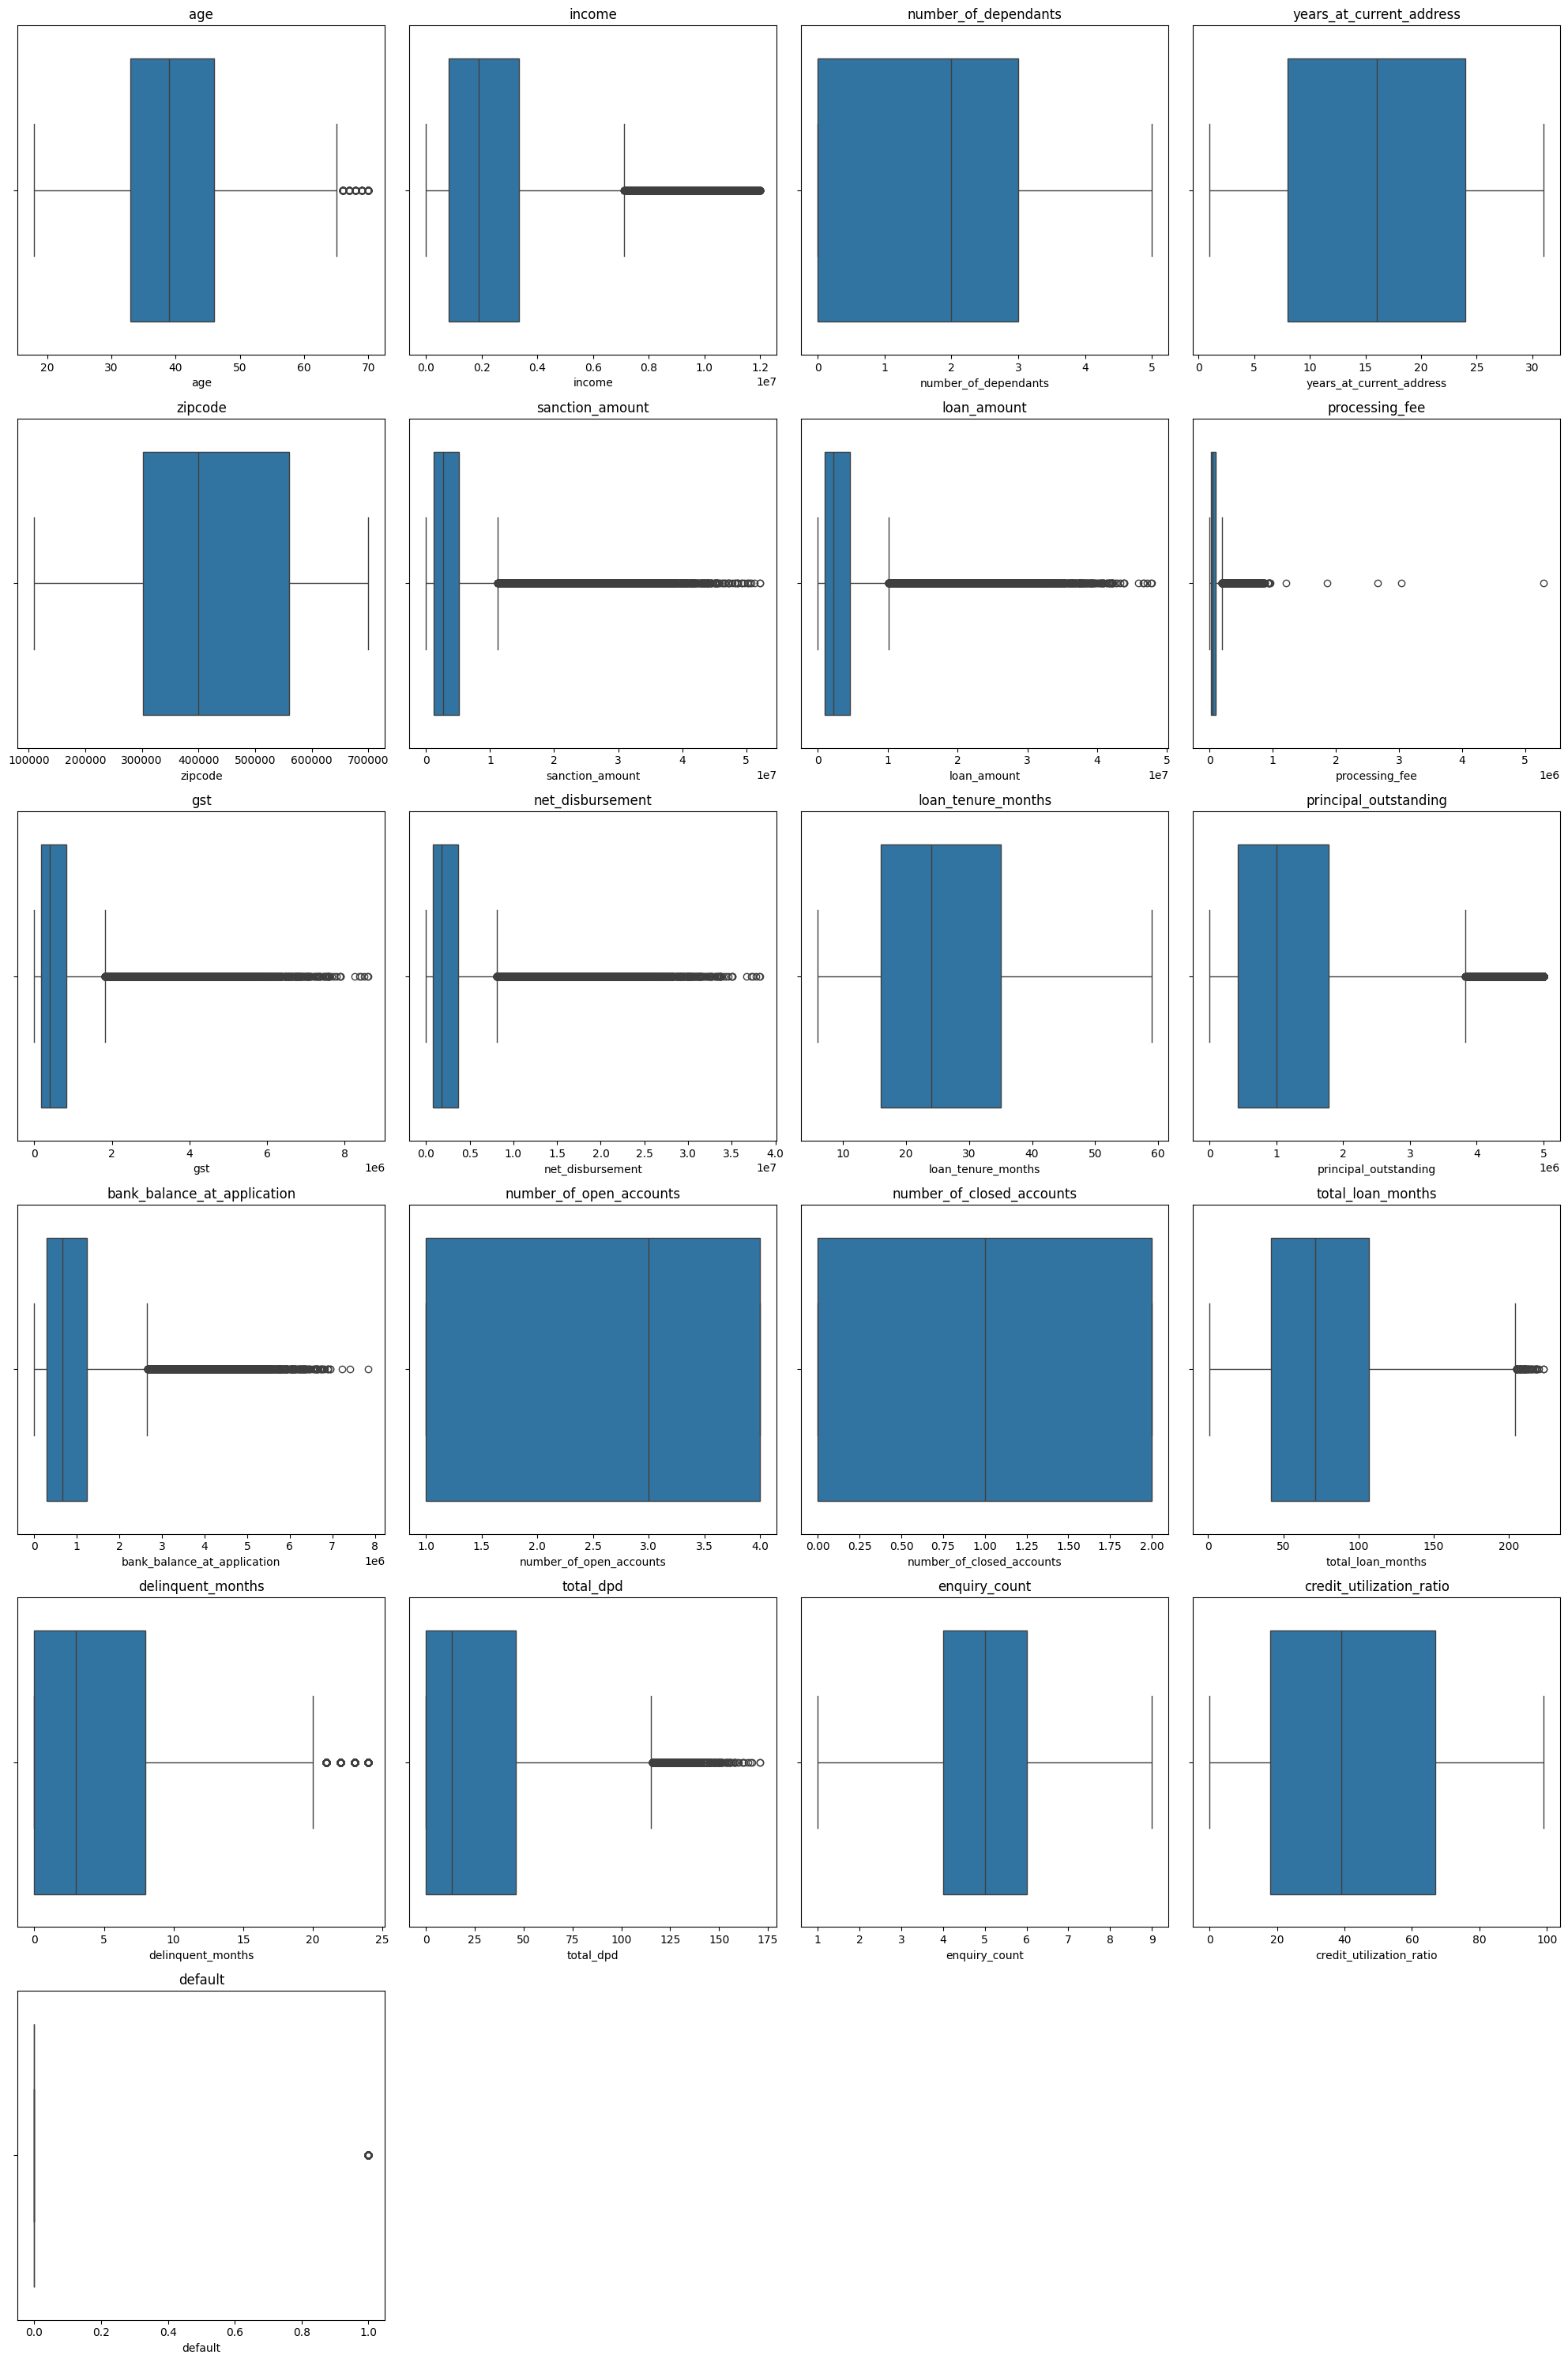

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

num_cols = df_train.select_dtypes(include='number').columns

n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=df_train[col],
        ax=axes[i]
    )
    axes[i].set_title(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

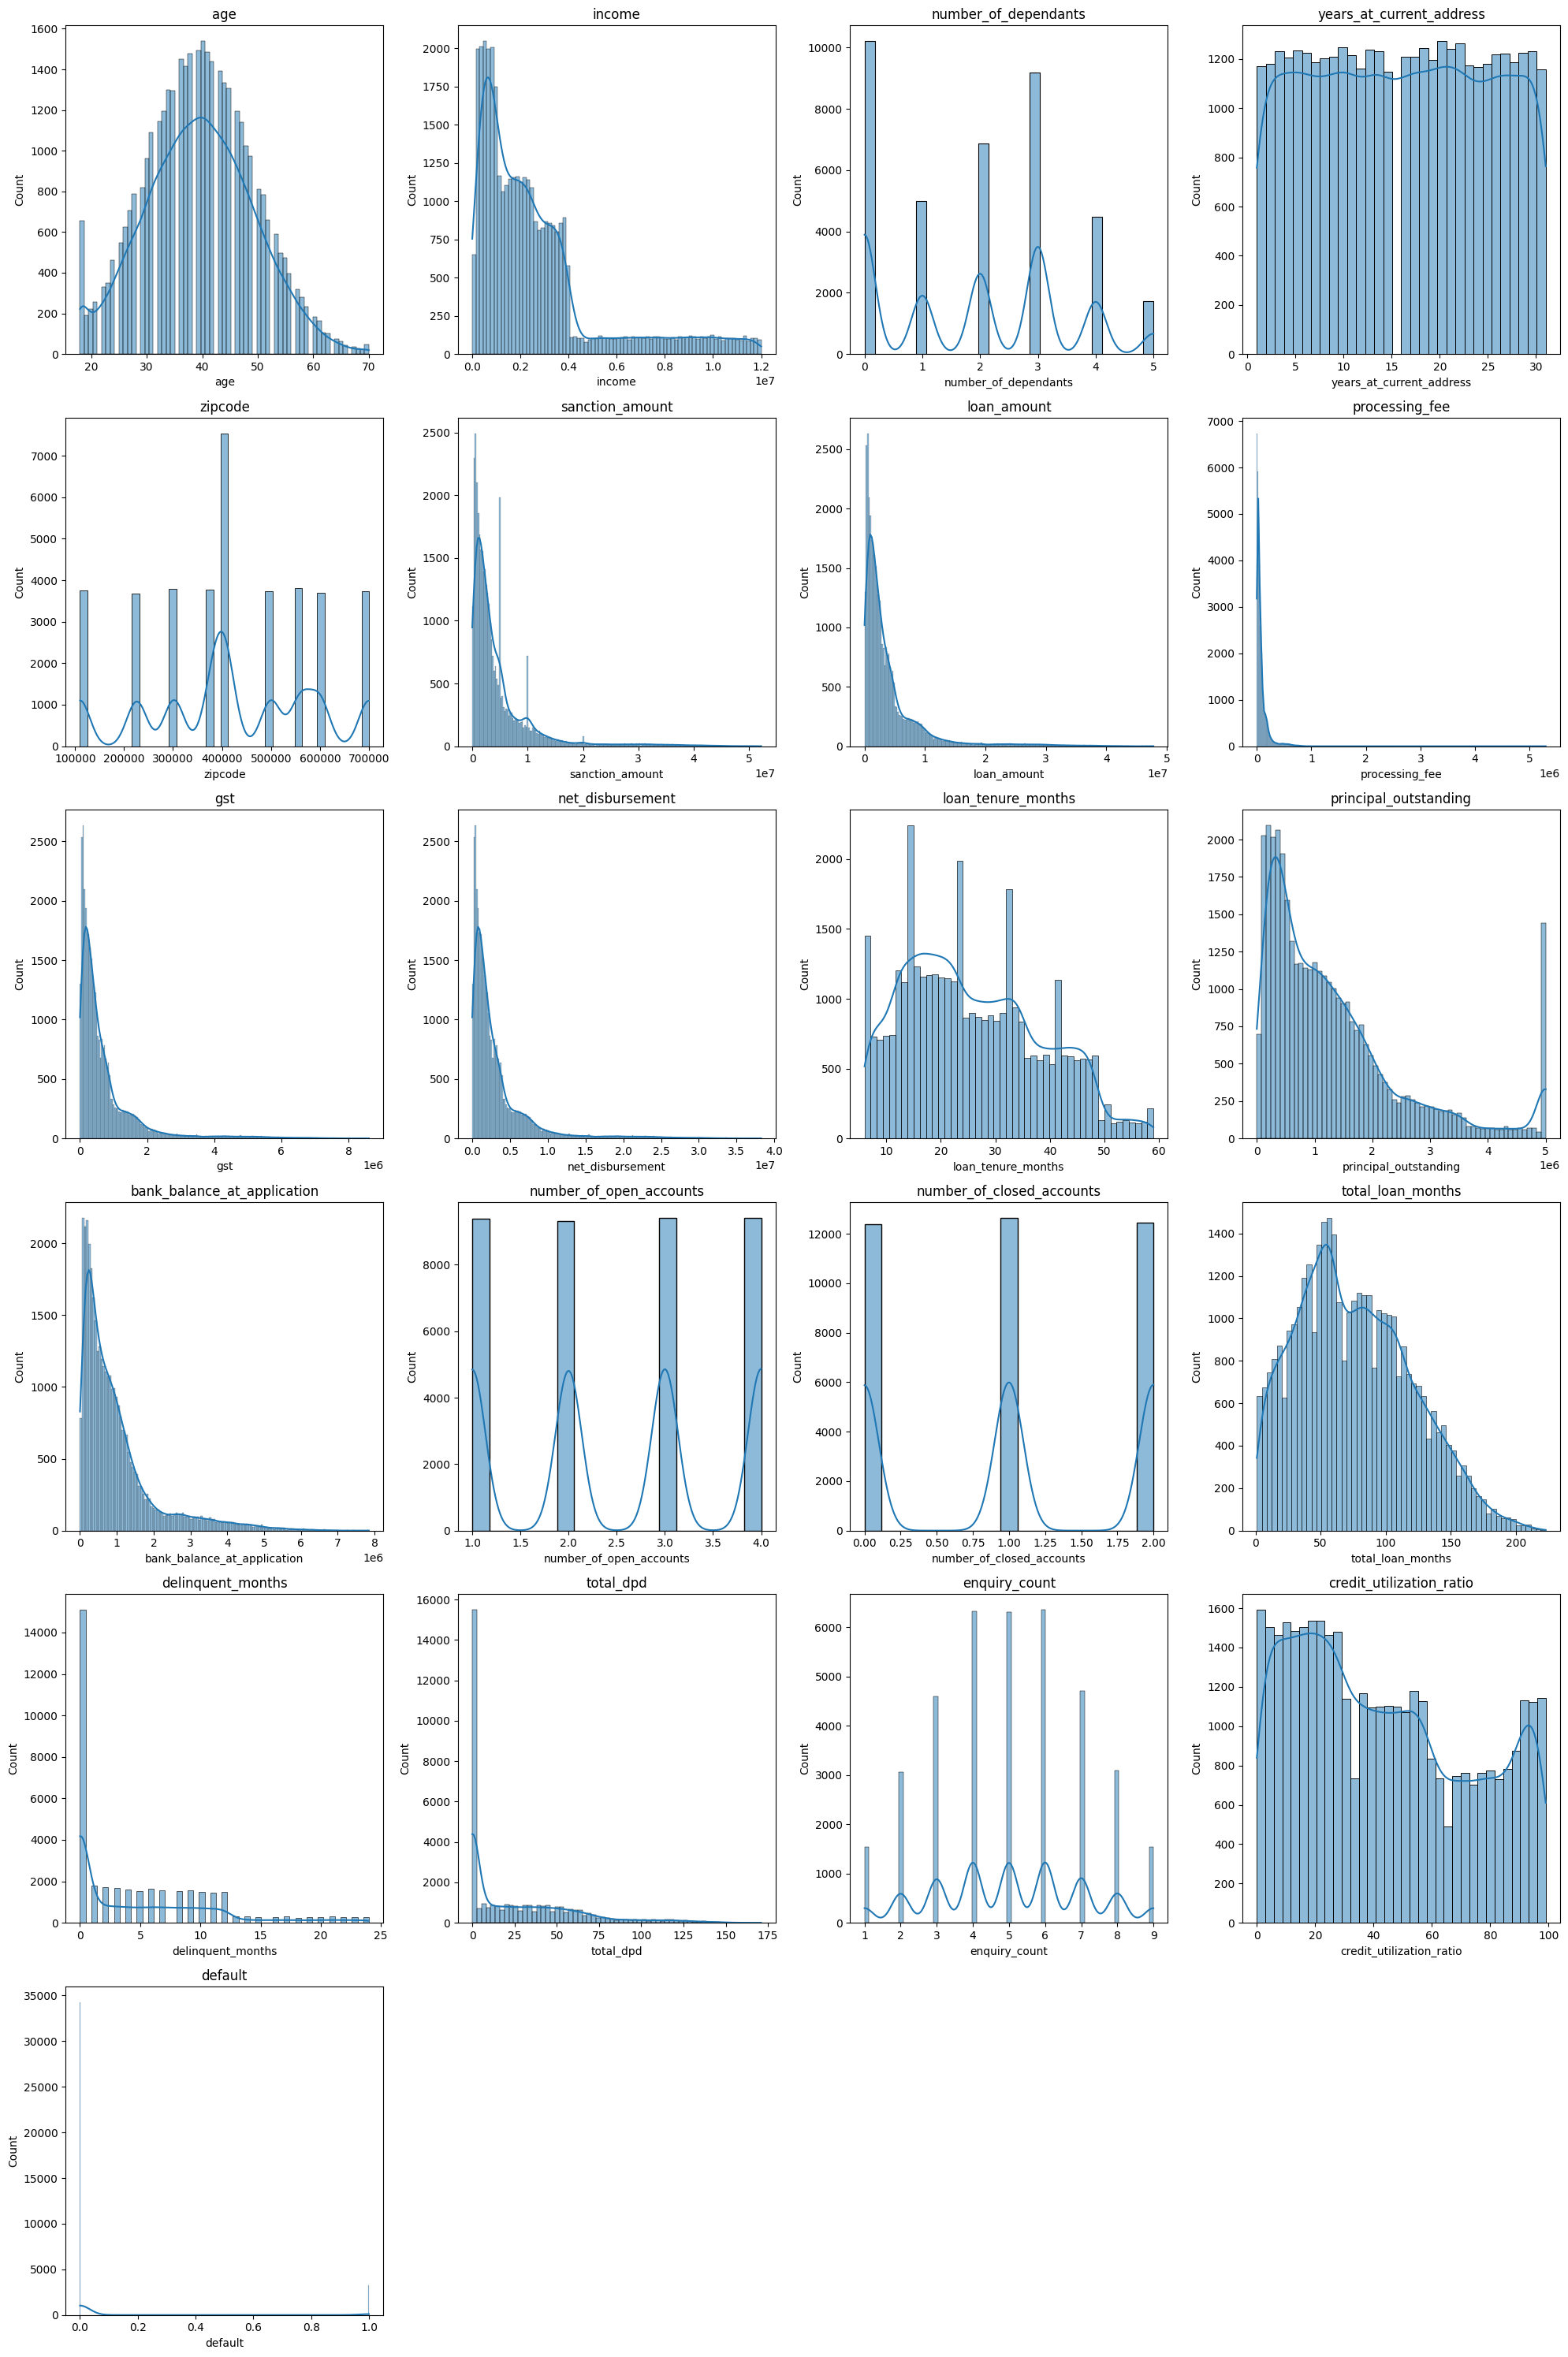

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

num_cols = df_train.select_dtypes(include='number').columns

n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        df_train[col],
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [33]:
# from the graph -> i need to work on bureau and loans dataset 
df_train[df_train['sanction_amount']==df_train['loan_amount']]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
45224,C45225,43,M,Married,Salaried,0,4,Mortgage,30,Chennai,...,2024-01-30,2024-02-27,3,1,112,10,53,7,30,0
2278,C02279,46,M,Married,Self-Employed,0,2,Rented,26,Pune,...,2019-10-15,2019-11-03,4,2,129,0,0,7,15,0
11092,C11093,39,F,Single,Salaried,0,0,Rented,17,Chennai,...,2020-09-01,2020-09-08,2,1,67,0,0,5,12,0
46640,C46641,28,F,Married,Salaried,0,4,Rented,24,Jaipur,...,2024-03-22,2024-04-08,2,0,73,0,0,6,30,0
47428,C47429,27,M,Single,Self-Employed,0,0,Owned,19,Lucknow,...,2024-04-19,2024-05-13,4,0,99,15,87,4,37,0
13356,C13357,34,F,Single,Self-Employed,0,1,Owned,2,Delhi,...,2020-11-23,2020-12-21,2,2,63,22,125,3,28,0
27457,C27458,48,F,Married,Self-Employed,0,3,Owned,5,Pune,...,2022-04-21,2022-05-12,4,1,72,0,0,7,89,0


In [34]:
7*100/73493

0.00952471663967997

In [35]:
df_train['processing_fee'].describe().apply(lambda x: f"{x:,.2f}")

count       37,500.00
mean        80,290.68
std        113,128.14
min              0.00
25%         19,220.00
50%         44,600.00
75%         92,420.00
max      5,293,543.52
Name: processing_fee, dtype: object

In [36]:
max_fee = df_train['processing_fee'].max()

df_train[df_train['processing_fee'] == max_fee][['loan_amount','processing_fee']]

,loan_amount,processing_fee
9898,3626000,5.293544e+06


In [37]:
df_train[df_train['processing_fee']>df_train['loan_amount']]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
23981,C23982,33,F,Single,Self-Employed,1790000,0,Rented,7,Kolkata,...,2021-12-15,2022-01-14,4,2,154,9,31,6,26,0
28174,C28175,36,F,Single,Self-Employed,1123000,1,Rented,31,Hyderabad,...,2022-05-18,2022-06-05,3,0,111,8,41,3,62,0
47089,C47090,37,M,Married,Self-Employed,1892000,2,Rented,13,Jaipur,...,2024-04-07,2024-04-15,3,0,112,5,33,3,32,0
29305,C29306,52,M,Married,Self-Employed,3839000,2,Owned,11,Delhi,...,2022-06-28,2022-07-21,2,2,42,11,65,3,2,0
9898,C09899,56,M,Married,Self-Employed,8948000,5,Owned,16,Ahmedabad,...,2020-07-19,2020-08-11,2,1,51,1,5,3,92,0


In [38]:
df_train_1 = df_train[(df_train['processing_fee']/df_train['loan_amount'])<0.03].copy()
df_test_1 = df_test[(df_test['processing_fee']/df_test['loan_amount'])<0.03].copy()



In [39]:
df_train_1[df_train_1.disbursal_date >= df_train_1.installment_start_dt]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default


In [40]:
cat_cols = [
    'gender',
    'marital_status',
    'employment_status',
    'residence_type',
    'city',
    'state',
    'zipcode',
    'loan_purpose',
    'loan_type',
    'default'
]



In [41]:
for col in cat_cols:
    print(col,"---->",df_train_1[col].unique())

gender ----> ['M' 'F']
marital_status ----> ['Married' 'Single']
employment_status ----> ['Self-Employed' 'Salaried']
residence_type ----> ['Owned' 'Mortgage' 'Rented']
city ----> ['Hyderabad' 'Mumbai' 'Chennai' 'Bangalore' 'Pune' 'Kolkata' 'Ahmedabad'
 'Delhi' 'Lucknow' 'Jaipur']
state ----> ['Telangana' 'Maharashtra' 'Tamil Nadu' 'Karnataka' 'West Bengal'
 'Gujarat' 'Delhi' 'Uttar Pradesh' 'Rajasthan']
zipcode ----> [500001 400001 600001 560001 411001 700001 380001 110001 226001 302001]
loan_purpose ----> ['Home' 'Education' 'Personal' 'Auto' 'Personaal']
loan_type ----> ['Secured' 'Unsecured']
default ----> [0 1]


In [42]:
df_train_1['loan_purpose'] = df_train_1['loan_purpose'].replace('Personaal','Personal')
df_test_1['loan_purpose'] = df_test_1['loan_purpose'].replace('Personaal','Personal')

In [43]:
df_train_1[(df_train_1.gst/df_train_1.loan_amount)>0.2]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default


In [44]:
df_train_1[df_train_1.net_disbursement>df_train_1.loan_amount].shape

(0, 33)

<h3 align ='center' style = "color:yellow">Exploratory Data Analysis </h3>

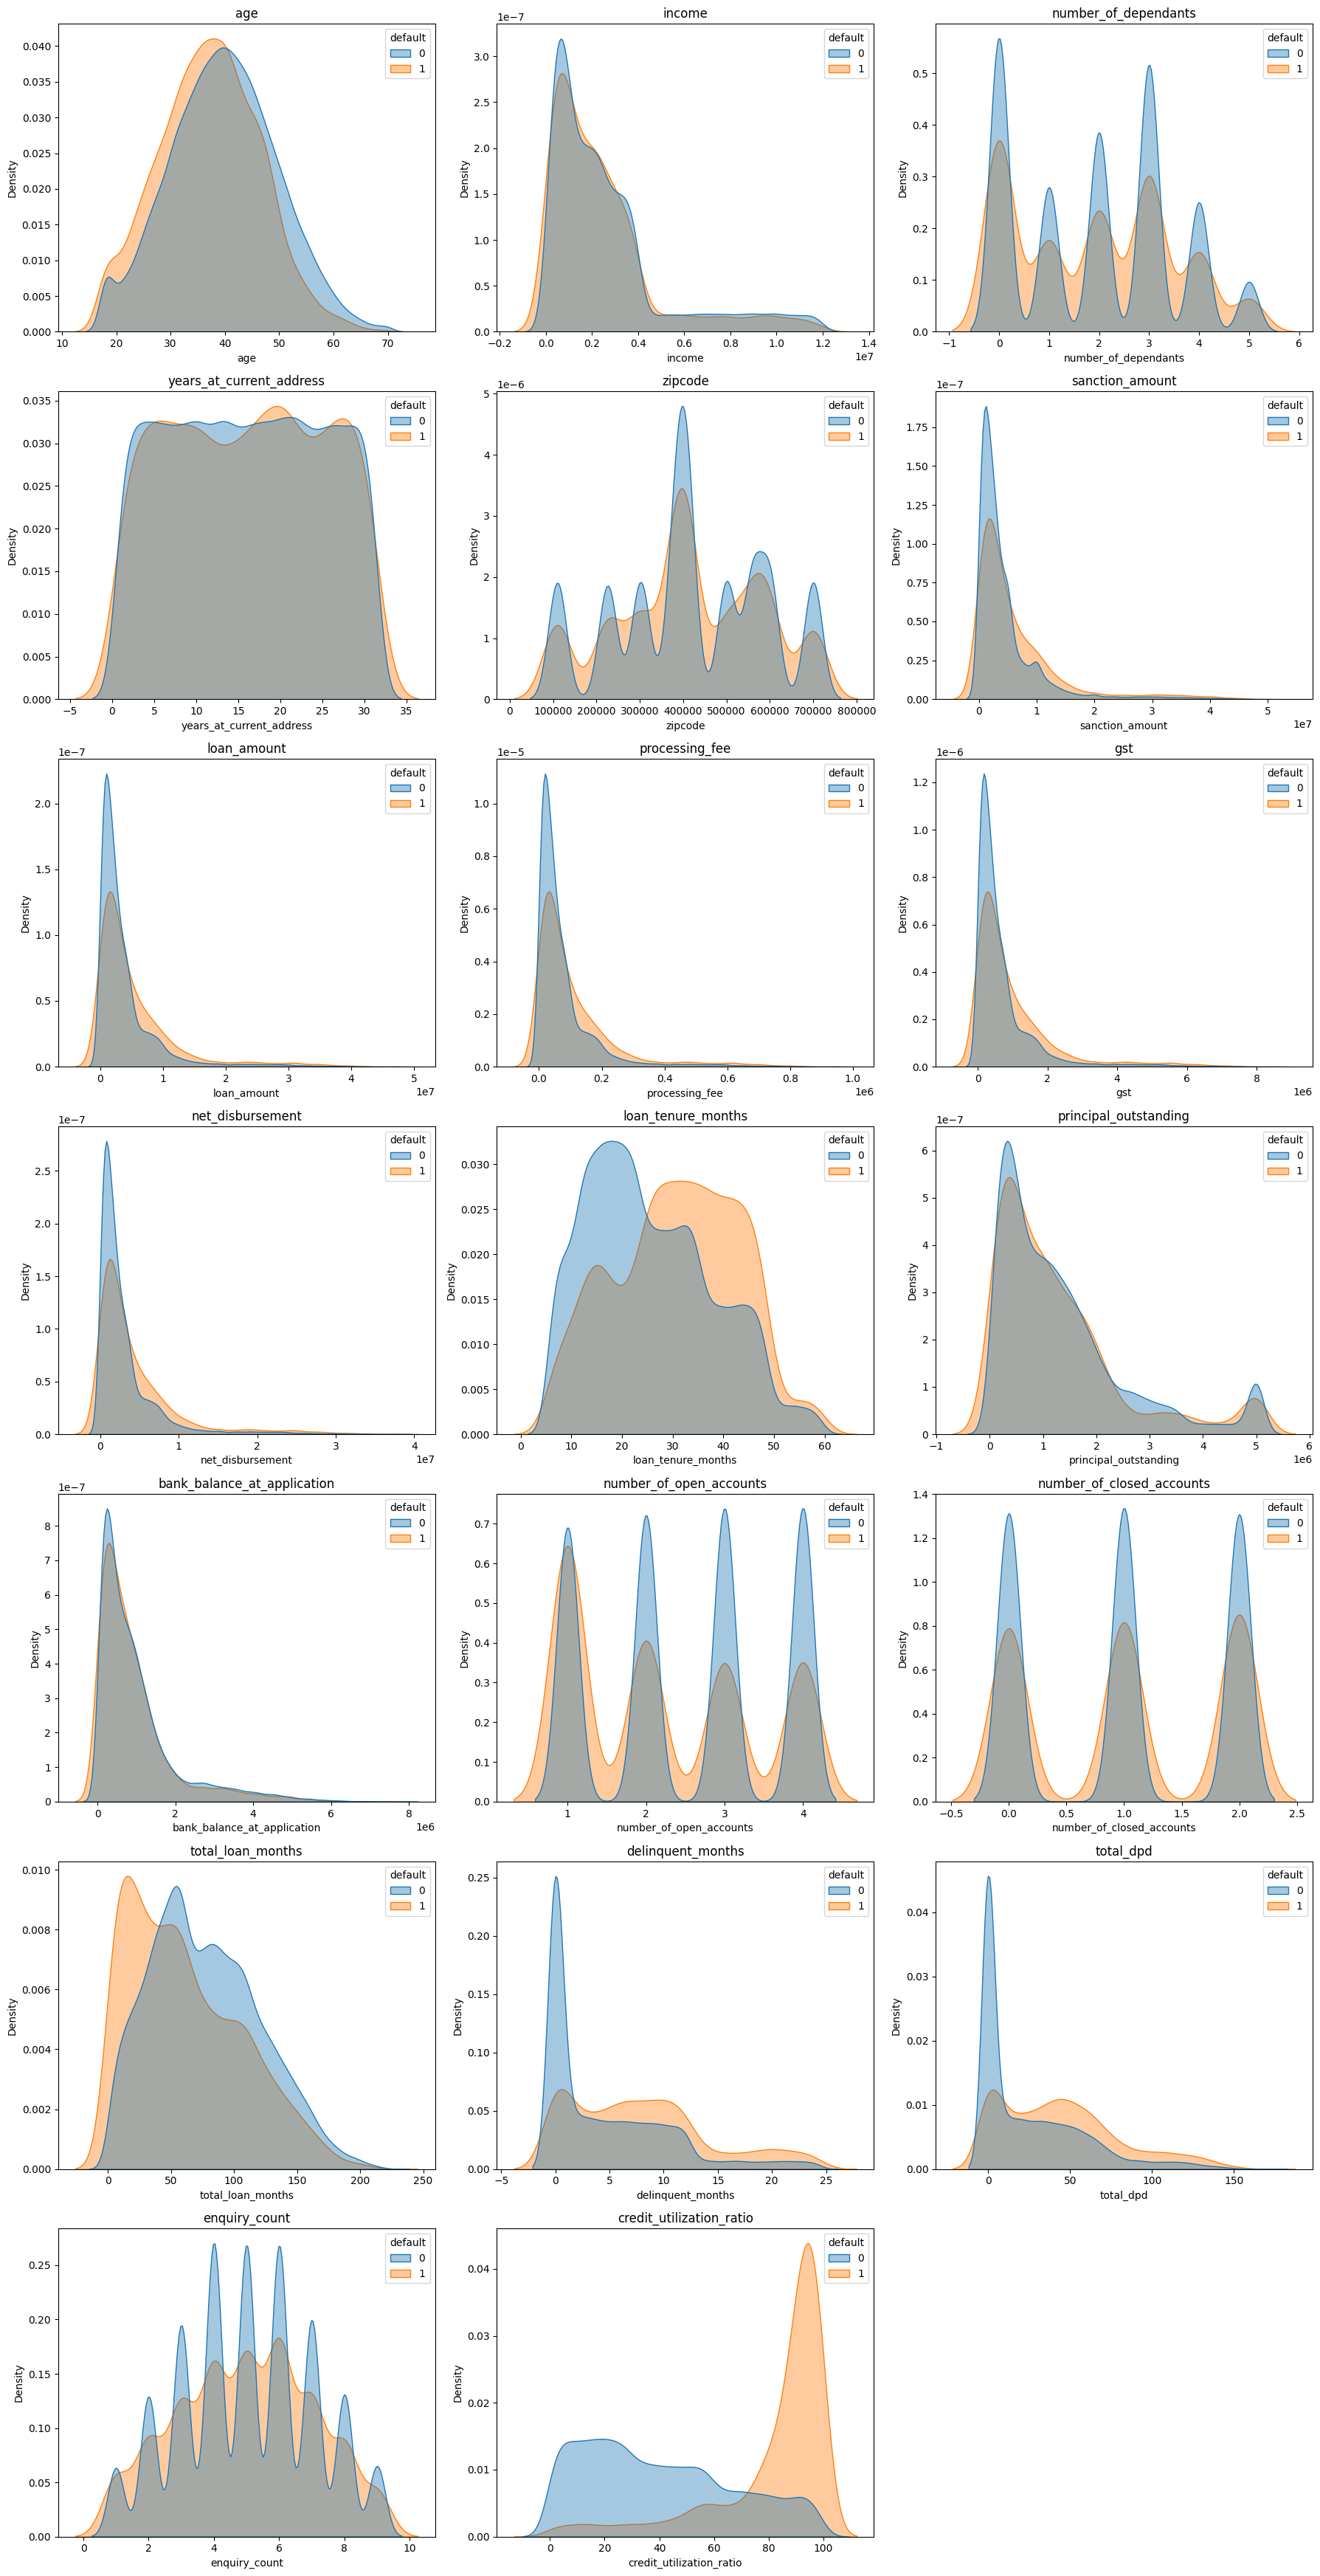

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

num_cols = df_train_1.select_dtypes(include='number').columns
num_cols = [col for col in num_cols if col != 'default']

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):

    sns.kdeplot(
        data=df_train_1,
        x=col,
        hue='default',
        fill=True,
        common_norm=False,
        alpha=0.4,
        ax=axes[i]
    )

    axes[i].set_title(col)

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### INSIGHTS :
1. young population less default 
2. young population lower credit_utilisation_Ratio
3. young population have lower dpd and delinquent_months
4. young population take lown for less tenure
(age,credit_utilisation_ratio,dpt,delinquent_months,total_months_tenure strong predictors)


<h1 align ='center' style = "color:yellow" >FEATURE ENGINEERING <h1/>

In [46]:
df_train_1['loan_to_income'] = round((df_train_1.loan_amount / df_train_1.income),2)
df_test_1['loan_to_income'] = round((df_test_1.loan_amount / df_test_1.income),2)
df_train_1[['loan_amount','income','loan_to_income']]

,loan_amount,income,loan_to_income
12746,23442000,11327000,2.07
32495,1149000,715000,1.61
43675,11296000,3195000,3.54
9040,1695000,1500000,1.13
13077,905000,1817000,0.50
...,...,...,...
28515,1420000,2470000,0.57
5558,2753000,2472000,1.11
45236,4479000,1329000,3.37
49228,1890000,1274000,1.48


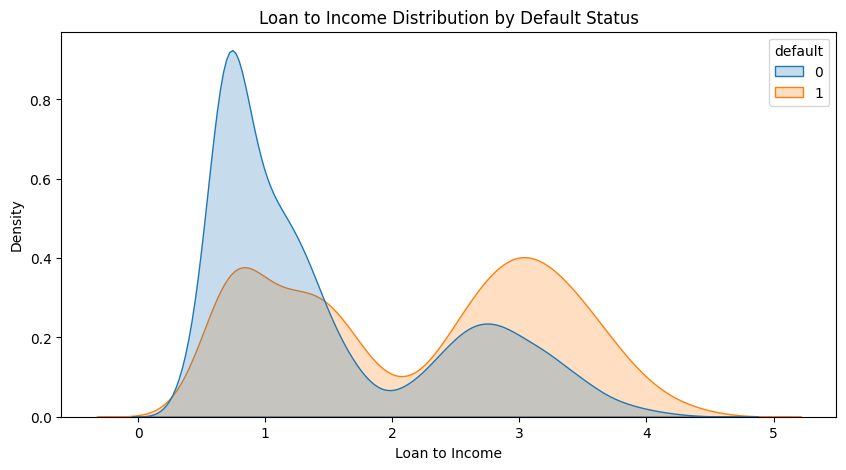

In [47]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    data=df_train_1,
    x='loan_to_income',
    hue='default',
    fill=True,
    common_norm=False
)

plt.title('Loan to Income Distribution by Default Status')
plt.xlabel('Loan to Income')
plt.ylabel('Density')
plt.show()

In [48]:
df_train_1['deliquency_ratio'] = round((df_train_1.delinquent_months / df_train_1.total_loan_months),2)
df_test_1['deliquency_ratio'] = round((df_test_1.delinquent_months / df_test_1.total_loan_months),2)


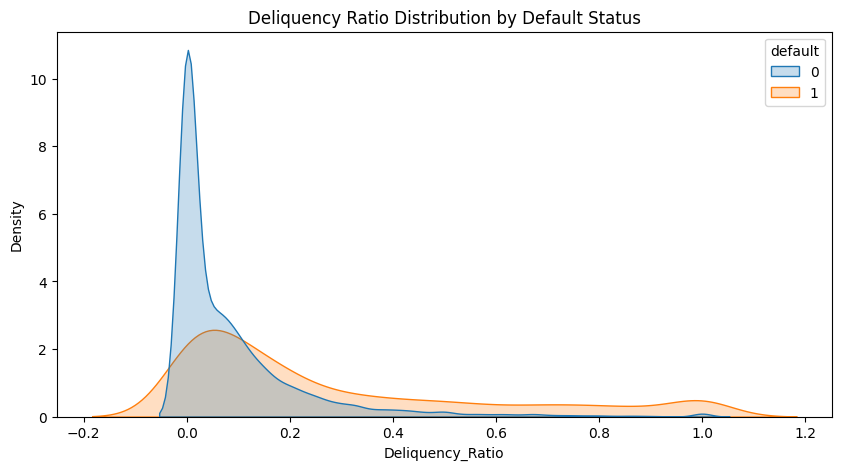

In [49]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    data=df_train_1,
    x='deliquency_ratio',
    hue='default',
    fill=True,
    common_norm=False
)

plt.title('Deliquency Ratio Distribution by Default Status')
plt.xlabel('Deliquency_Ratio')
plt.ylabel('Density')
plt.show()

In [50]:
df_train_1['avg_dpd_per_deliquency'] = np.where(df_train_1['delinquent_months'] != 0,
(df_train_1['total_dpd'] / df_train_1['delinquent_months']).round(2),0)


df_test_1['avg_dpd_per_deliquency'] = np.where(df_test_1['delinquent_months'] != 0,
(df_test_1['total_dpd'] / df_test_1['delinquent_months']).round(2),0)

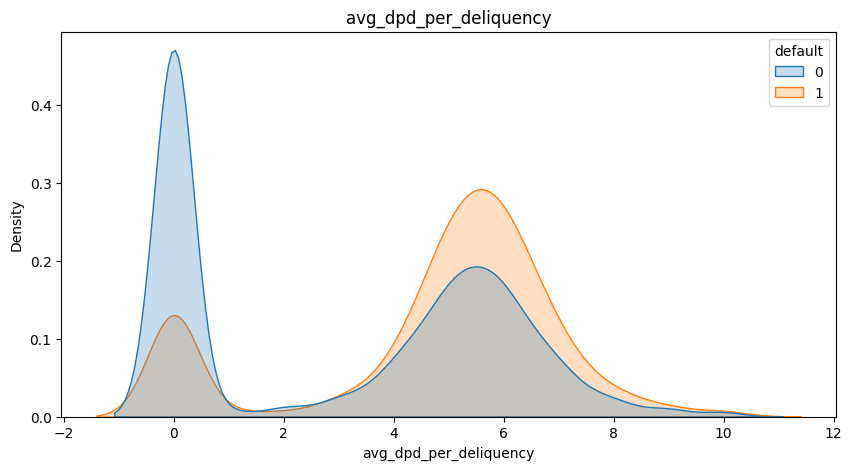

In [51]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    data=df_train_1,
    x='avg_dpd_per_deliquency',
    hue='default',
    fill=True,
    common_norm=False
)

plt.title('avg_dpd_per_deliquency')
plt.xlabel('avg_dpd_per_deliquency')
plt.ylabel('Density')
plt.show()

In [52]:
df_train_1[df_train_1.loan_to_income==0]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default,loan_to_income,deliquency_ratio,avg_dpd_per_deliquency


In [53]:
df_train_1.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default',
       'loan_to_income', 'deliquency_ratio', 'avg_dpd_per_deliquency'],
      dtype='object')

In [54]:
df_train_2 = df_train_1.drop(['cust_id','loan_id','disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 
                              'total_loan_months', 'delinquent_months', 'total_dpd'], axis=1)

df_test_2 = df_test_1.drop(['cust_id','loan_id','disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 
                              'total_loan_months', 'delinquent_months', 'total_dpd'], axis=1)

In [55]:
df_train_2.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'deliquency_ratio', 'avg_dpd_per_deliquency'],
      dtype='object')

In [56]:
df_train_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37488 entries, 12746 to 37784
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          37488 non-null  int64  
 1   gender                       37488 non-null  object 
 2   marital_status               37488 non-null  object 
 3   employment_status            37488 non-null  object 
 4   number_of_dependants         37488 non-null  int64  
 5   residence_type               37488 non-null  object 
 6   years_at_current_address     37488 non-null  int64  
 7   city                         37488 non-null  object 
 8   state                        37488 non-null  object 
 9   zipcode                      37488 non-null  int64  
 10  loan_purpose                 37488 non-null  object 
 11  loan_type                    37488 non-null  object 
 12  sanction_amount              37488 non-null  int64  
 13  processing_fee   

In [57]:
df_train_2.select_dtypes(['int','float'])

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,default,loan_to_income,deliquency_ratio,avg_dpd_per_deliquency
12746,59,3,30,500001,33121000,468840.0,4219560,18753600,28,5000000,4820526,4,2,4,36,0,2.07,0.13,5.90
32495,44,0,27,400001,1175000,22980.0,206820,919200,50,467229,216697,3,1,5,5,0,1.61,0.06,6.20
43675,38,0,26,600001,11409000,225920.0,2033280,9036800,32,1656773,1383842,1,1,4,0,0,3.54,0.22,5.58
9040,42,2,30,560001,2336000,33900.0,305100,1356000,40,1023442,626203,3,0,8,87,0,1.13,0.00,0.00
13077,58,4,29,411001,1167000,18100.0,162900,724000,15,651599,585099,1,2,1,71,0,0.50,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28515,70,0,20,700001,1562000,28400.0,255600,1136000,12,1022399,501594,2,0,5,13,0,0.57,0.00,0.00
5558,39,0,26,700001,3208000,55060.0,495540,2202400,32,1123466,587429,1,0,4,44,0,1.11,0.27,5.14
45236,39,4,10,411001,4804000,89580.0,806220,3583200,38,913243,517025,4,2,6,97,1,3.37,0.08,4.00
49228,33,2,26,600001,2451000,37800.0,340200,1512000,37,635515,475147,2,1,6,25,0,1.48,0.00,0.00


In [58]:
X_train = df_train_2.drop('default', axis='columns')
y_train = df_train_2['default']

# ------------------------------

X_test = df_test_2.drop('default', axis='columns')
y_test = df_test_2['default']

In [59]:
# ── 1. Select only numeric columns, drop target and non-meaningful columns ──
cols_to_exclude = ['default', 'zipcode']

# ── Train ──
X_train_num = df_train_2.drop(columns=cols_to_exclude, errors='ignore') \
    .select_dtypes(include=['int64', 'float64'])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)   # fit + transform on train
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_num.columns)

# ── Test ──
X_test_num = df_test_2.drop(columns=cols_to_exclude, errors='ignore')\
    .select_dtypes(include=['int64', 'float64'])

X_test_scaled = scaler.transform(X_test_num)        
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test_num.columns)
# ── 3. Compute VIF ──
def compute_vif(df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    vif_data["VIF"] = [
        variance_inflation_factor(df.values, i)
        for i in range(df.shape[1])
    ]
    vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)
    return vif_data

vif_result = compute_vif(X_train_scaled_df)
print("\n── VIF Results ──")
print(vif_result.to_string(index=False))

# ── 4. Flag problematic columns ──
print("\n── High Multicollinearity (VIF > 10) ──")
print(vif_result[vif_result["VIF"] > 10].to_string(index=False))

print("\n── Moderate (5 < VIF ≤ 10) ──")
print(vif_result[(vif_result["VIF"] > 5) & (vif_result["VIF"] <= 10)].to_string(index=False))


── VIF Results ──
                    Feature       VIF
             processing_fee       inf
           net_disbursement       inf
                        gst       inf
            sanction_amount 65.352301
      principal_outstanding  7.631598
bank_balance_at_application  5.130036
             loan_to_income  2.802597
         loan_tenure_months  1.753355
    number_of_open_accounts  1.579835
           deliquency_ratio  1.450207
              enquiry_count  1.417719
     avg_dpd_per_deliquency  1.298172
                        age  1.156870
       number_of_dependants  1.069033
  number_of_closed_accounts  1.002138
   credit_utilization_ratio  1.000699
   years_at_current_address  1.000463

── High Multicollinearity (VIF > 10) ──
         Feature       VIF
  processing_fee       inf
net_disbursement       inf
             gst       inf
 sanction_amount 65.352301

── Moderate (5 < VIF ≤ 10) ──
                    Feature      VIF
      principal_outstanding 7.631598
bank_balance_at_

In [60]:
features_to_drop_vif = ['sanction_amount', 'processing_fee', 'gst', 'net_disbursement', 'principal_outstanding']

cols_to_drop_all = cols_to_exclude + features_to_drop_vif   # combine both drop lists
X_train_1 = X_train.drop(features_to_drop_vif, axis='columns')

X_train_1_num = df_train_2.drop(columns=cols_to_drop_all, errors='ignore') \
                            .select_dtypes(include=['int64', 'float64'])   

X_train_1_scaled = scaler.fit_transform(X_train_1_num)
X_train_1_scaled_df = pd.DataFrame(X_train_1_scaled, columns=X_train_1_num.columns) 
vif_result = compute_vif(X_train_1_scaled_df)
print("\n── VIF Results ──")
print(vif_result.to_string(index=False))

print("\n── High Multicollinearity (VIF > 10) ──")
print(vif_result[vif_result["VIF"] > 10].to_string(index=False))

print("\n── Moderate (5 < VIF ≤ 10) ──")
print(vif_result[(vif_result["VIF"] > 5) & (vif_result["VIF"] <= 10)].to_string(index=False))


── VIF Results ──
                    Feature      VIF
             loan_to_income 1.767232
         loan_tenure_months 1.712562
    number_of_open_accounts 1.570395
           deliquency_ratio 1.450173
              enquiry_count 1.417672
     avg_dpd_per_deliquency 1.298100
                        age 1.120474
       number_of_dependants 1.068919
bank_balance_at_application 1.003179
   credit_utilization_ratio 1.000635
   years_at_current_address 1.000320
  number_of_closed_accounts 1.000300

── High Multicollinearity (VIF > 10) ──
Empty DataFrame
Columns: [Feature, VIF]
Index: []

── Moderate (5 < VIF ≤ 10) ──
Empty DataFrame
Columns: [Feature, VIF]
Index: []


In [61]:
X_train_1_num.columns


Index(['age', 'number_of_dependants', 'years_at_current_address',
       'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'deliquency_ratio',
       'avg_dpd_per_deliquency'],
      dtype='object')

In [62]:
numeric_columns = X_train_1.select_dtypes(['int64', 'float64']).columns
numeric_columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'deliquency_ratio',
       'avg_dpd_per_deliquency'],
      dtype='object')

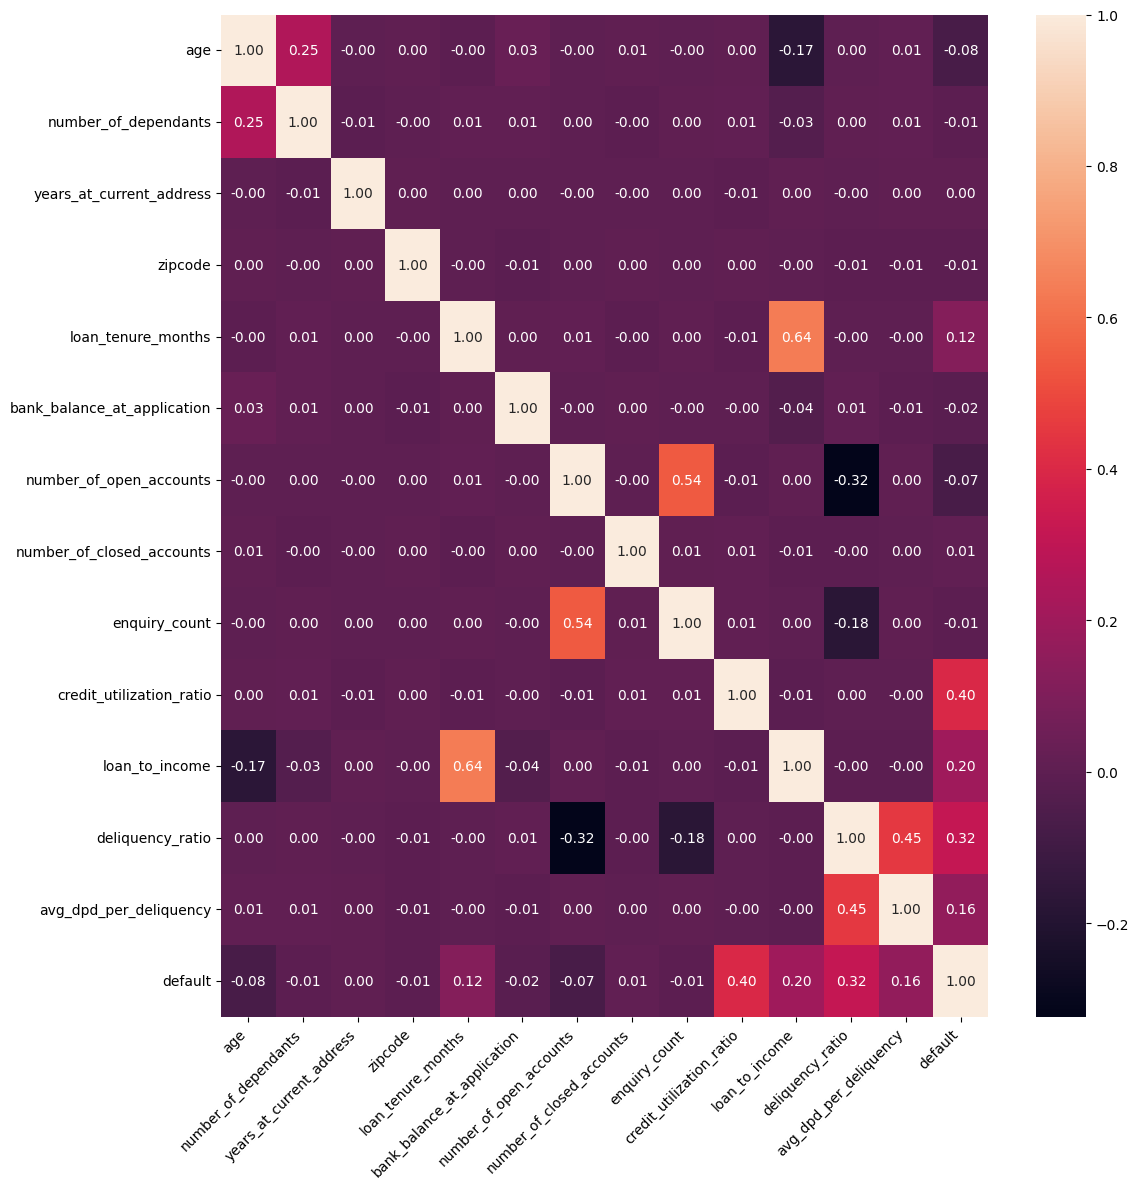

In [63]:
plt.figure(figsize=(12,12))
cm = df_train_2[numeric_columns.append(pd.Index(['default']))].corr()
sns.heatmap(cm, annot=True, fmt='0.2f')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### WOE AND IV


In [64]:
def calculate_woe_iv(df,feature,target):
    grouped = df.groupby(feature)[target].agg(['count','sum'])
    grouped = grouped.rename(columns ={'count':'total','sum':'defaulters'})
    grouped['non_defaulters'] = grouped['total'] - grouped['defaulters']
    total_defaulters = grouped['defaulters'].sum()
    total_non_defaulters = grouped['non_defaulters'].sum()
    grouped['defaulters_pct'] = grouped['defaulters']/total_defaulters
    grouped['non_defaulters_pct'] = grouped['non_defaulters']/total_non_defaulters
    grouped['woe'] = np.where((grouped['defaulters_pct'] != 0) &(grouped['non_defaulters_pct'] != 0),np.log(grouped['defaulters_pct'] /grouped['non_defaulters_pct']),0)
    grouped['iv'] = (grouped['defaulters_pct'] - grouped['non_defaulters_pct'])*grouped['woe']
    total_iv = grouped['iv'].sum()

    return grouped,total_iv

grouped, total_iv = calculate_woe_iv(pd.concat([X_train_1, y_train],axis=1), 'loan_purpose', 'default')
grouped.round(2)   

  

,total,defaulters,non_defaulters,defaulters_pct,non_defaulters_pct,woe,iv
loan_purpose,,,,,,,
Auto,7447,327,7120,0.10,0.21,-0.72,0.08
Education,5620,559,5061,0.17,0.15,0.16,0.00
Home,11304,1734,9570,0.54,0.28,0.66,0.17
Personal,13117,603,12514,0.19,0.37,-0.67,0.12


In [65]:
iv_values = {}
for feature in X_train_1.columns:
    if(X_train_1[feature].dtype=='object'):
        _,iv = calculate_woe_iv(pd.concat([X_train_1,y_train],axis=1),feature,'default')
    else:
        X_binned = pd.cut(X_train_1[feature],bins=10,labels=False)
        _,iv = calculate_woe_iv(pd.concat([X_binned,y_train],axis=1),feature,'default')
    iv_values[feature] = round(float(iv), 4)
iv_values    

{'age': 0.0887,
 'gender': 0.0005,
 'marital_status': 0.0011,
 'employment_status': 0.004,
 'number_of_dependants': 0.0019,
 'residence_type': 0.2467,
 'years_at_current_address': 0.0022,
 'city': 0.0019,
 'state': 0.0019,
 'zipcode': 0.0017,
 'loan_purpose': 0.3691,
 'loan_type': 0.1632,
 'loan_tenure_months': 0.2189,
 'bank_balance_at_application': 0.0063,
 'number_of_open_accounts': 0.0846,
 'number_of_closed_accounts': 0.0012,
 'enquiry_count': 0.0079,
 'credit_utilization_ratio': 2.353,
 'loan_to_income': 0.4764,
 'deliquency_ratio': 0.7132,
 'avg_dpd_per_deliquency': 0.4018}

In [66]:
iv_df = pd.DataFrame(list(iv_values.items()), columns=['Feature', 'IV'])
iv_df = iv_df.sort_values(by='IV', ascending=False)
iv_df

,Feature,IV
17,credit_utilization_ratio,2.3530
19,deliquency_ratio,0.7132
18,loan_to_income,0.4764
20,avg_dpd_per_deliquency,0.4018
10,loan_purpose,0.3691
5,residence_type,0.2467
12,loan_tenure_months,0.2189
11,loan_type,0.1632
0,age,0.0887
14,number_of_open_accounts,0.0846


In [67]:
selected_features_df = iv_df[iv_df.IV >0.02]
selected_features_df

,Feature,IV
17,credit_utilization_ratio,2.3530
19,deliquency_ratio,0.7132
18,loan_to_income,0.4764
20,avg_dpd_per_deliquency,0.4018
10,loan_purpose,0.3691
5,residence_type,0.2467
12,loan_tenure_months,0.2189
11,loan_type,0.1632
0,age,0.0887
14,number_of_open_accounts,0.0846


In [68]:
selected_features = selected_features_df['Feature'].tolist()
selected_features

['credit_utilization_ratio',
 'deliquency_ratio',
 'loan_to_income',
 'avg_dpd_per_deliquency',
 'loan_purpose',
 'residence_type',
 'loan_tenure_months',
 'loan_type',
 'age',
 'number_of_open_accounts']

In [69]:
X_train_reduced = X_train_1[selected_features]
X_test_reduced = X_test[selected_features]
X_train_reduced

,credit_utilization_ratio,deliquency_ratio,loan_to_income,avg_dpd_per_deliquency,loan_purpose,residence_type,loan_tenure_months,loan_type,age,number_of_open_accounts
12746,36,0.13,2.07,5.90,Home,Owned,28,Secured,59,4
32495,5,0.06,1.61,6.20,Education,Owned,50,Secured,44,3
43675,0,0.22,3.54,5.58,Home,Mortgage,32,Secured,38,1
9040,87,0.00,1.13,0.00,Education,Mortgage,40,Secured,42,3
13077,71,0.00,0.50,0.00,Personal,Owned,15,Unsecured,58,1
...,...,...,...,...,...,...,...,...,...,...
28515,13,0.00,0.57,0.00,Personal,Owned,12,Unsecured,70,2
5558,44,0.27,1.11,5.14,Auto,Rented,32,Secured,39,1
45236,97,0.08,3.37,4.00,Home,Owned,38,Secured,39,4
49228,25,0.00,1.48,0.00,Education,Owned,37,Secured,33,2


In [70]:
X_train_encoded = pd.get_dummies(X_train_reduced, drop_first=True)
X_train_encoded

,credit_utilization_ratio,deliquency_ratio,loan_to_income,avg_dpd_per_deliquency,loan_tenure_months,age,number_of_open_accounts,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,residence_type_Owned,residence_type_Rented,loan_type_Unsecured
12746,36,0.13,2.07,5.90,28,59,4,False,True,False,True,False,False
32495,5,0.06,1.61,6.20,50,44,3,True,False,False,True,False,False
43675,0,0.22,3.54,5.58,32,38,1,False,True,False,False,False,False
9040,87,0.00,1.13,0.00,40,42,3,True,False,False,False,False,False
13077,71,0.00,0.50,0.00,15,58,1,False,False,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28515,13,0.00,0.57,0.00,12,70,2,False,False,True,True,False,True
5558,44,0.27,1.11,5.14,32,39,1,False,False,False,False,True,False
45236,97,0.08,3.37,4.00,38,39,4,False,True,False,True,False,False
49228,25,0.00,1.48,0.00,37,33,2,True,False,False,True,False,False


In [71]:
X_test_encoded = pd.get_dummies(X_test_reduced, drop_first=True)
X_test_encoded

,credit_utilization_ratio,deliquency_ratio,loan_to_income,avg_dpd_per_deliquency,loan_tenure_months,age,number_of_open_accounts,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,residence_type_Owned,residence_type_Rented,loan_type_Unsecured
19205,98,0.00,2.65,0.00,46,36,2,False,True,False,True,False,False
15514,32,0.00,1.24,0.00,18,43,4,True,False,False,True,False,False
30367,82,0.00,1.07,0.00,35,30,3,False,False,False,True,False,False
35347,48,0.02,2.74,7.00,46,37,4,False,True,False,True,False,False
41814,97,0.11,2.04,6.36,44,48,3,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29297,52,0.05,1.37,2.80,29,27,3,False,False,False,True,False,False
20567,5,0.00,3.17,0.00,35,40,1,False,True,False,False,True,False
681,54,0.06,0.31,3.50,15,28,2,False,False,True,False,True,True
33682,85,0.00,3.65,0.00,37,31,1,False,True,False,True,False,False


In [72]:
X_train_encoded.columns

Index(['credit_utilization_ratio', 'deliquency_ratio', 'loan_to_income',
       'avg_dpd_per_deliquency', 'loan_tenure_months', 'age',
       'number_of_open_accounts', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Personal', 'residence_type_Owned',
       'residence_type_Rented', 'loan_type_Unsecured'],
      dtype='object')

In [73]:
X_test_encoded.columns

Index(['credit_utilization_ratio', 'deliquency_ratio', 'loan_to_income',
       'avg_dpd_per_deliquency', 'loan_tenure_months', 'age',
       'number_of_open_accounts', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Personal', 'residence_type_Owned',
       'residence_type_Rented', 'loan_type_Unsecured'],
      dtype='object')

In [74]:
y_train.value_counts(normalize=True)*100

default
0    91.402582
1     8.597418
Name: proportion, dtype: float64

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, fbeta_score
)

from imblearn.over_sampling import SMOTE

import joblib
import warnings
warnings.filterwarnings('ignore')

In [76]:
# claude

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled  = scaler.transform(X_test_encoded)

print("Train shape:", X_train_scaled.shape)
print("Test shape :", X_test_scaled.shape)

Train shape: (37488, 13)
Test shape : (12497, 13)


In [77]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", pd.Series(y_train_smote).value_counts().to_dict())

Before SMOTE: {0: 34265, 1: 3223}
After SMOTE : {0: 34265, 1: 34265}


In [78]:
models_v1 = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest"      : RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    "XGBoost"            : XGBClassifier(scale_pos_weight=10, use_label_encoder=False,
                                         eval_metric='logloss', random_state=42)
}

models_v2 = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest"      : RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    "XGBoost"            : XGBClassifier(scale_pos_weight=1, use_label_encoder=False,
                                         eval_metric='logloss', random_state=42)
}

In [79]:
def evaluate_models(models, X_train, y_train, X_test, y_test, version_name):
    print(f"\n{'='*60}")
    print(f"  {version_name}")
    print(f"{'='*60}")

    results = {}

    for name, model in models.items():
        print(f"\n--- {name} ---")
        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)

        auc   = roc_auc_score(y_test, y_prob)
        f2    = fbeta_score(y_test, y_pred, beta=2)
        f1    = f1_score(y_test, y_pred)

        print(f"AUC-ROC : {auc:.4f}")
        print(f"F2 Score: {f2:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=['Non-Default', 'Default']))

        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(4, 3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Non-Default', 'Default'],
                    yticklabels=['Non-Default', 'Default'])
        plt.title(f"{version_name} | {name} — Confusion Matrix")
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.show()

        results[name] = {'model': model, 'auc': auc, 'f2': f2, 'f1': f1, 'y_prob': y_prob}

    return results

In [80]:
def evaluate_models(models, X_train, y_train, X_test, y_test, version_name):
    print(f"\n{'='*60}")
    print(f"  {version_name}")
    print(f"{'='*60}")

    results = {}

    for name, model in models.items():
        print(f"\n--- {name} ---")
        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)

        auc   = roc_auc_score(y_test, y_prob)
        f2    = fbeta_score(y_test, y_pred, beta=2)
        f1    = f1_score(y_test, y_pred)

        print(f"AUC-ROC : {auc:.4f}")
        print(f"F2 Score: {f2:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=['Non-Default', 'Default']))

        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(4, 3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Non-Default', 'Default'],
                    yticklabels=['Non-Default', 'Default'])
        plt.title(f"{version_name} | {name} — Confusion Matrix")
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.show()

        results[name] = {'model': model, 'auc': auc, 'f2': f2, 'f1': f1, 'y_prob': y_prob}

    return results


  Version 1: class_weight only

--- Logistic Regression ---
AUC-ROC : 0.9837
F2 Score: 0.8251
F1 Score: 0.6866

Classification Report:
              precision    recall  f1-score   support

 Non-Default       1.00      0.92      0.96     11423
     Default       0.54      0.95      0.69      1074

    accuracy                           0.93     12497
   macro avg       0.77      0.94      0.82     12497
weighted avg       0.96      0.93      0.93     12497



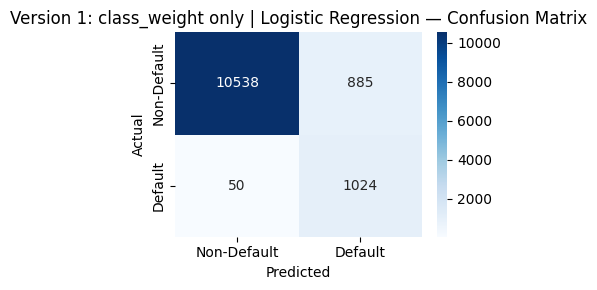


--- Random Forest ---
AUC-ROC : 0.9856
F2 Score: 0.7101
F1 Score: 0.7630

Classification Report:
              precision    recall  f1-score   support

 Non-Default       0.97      0.99      0.98     11423
     Default       0.87      0.68      0.76      1074

    accuracy                           0.96     12497
   macro avg       0.92      0.83      0.87     12497
weighted avg       0.96      0.96      0.96     12497



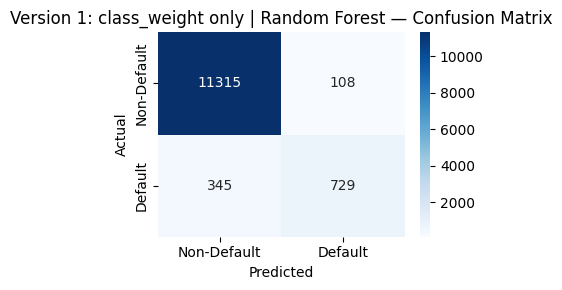


--- XGBoost ---
AUC-ROC : 0.9866
F2 Score: 0.8419
F1 Score: 0.7807

Classification Report:
              precision    recall  f1-score   support

 Non-Default       0.99      0.96      0.98     11423
     Default       0.70      0.89      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.84      0.93      0.88     12497
weighted avg       0.96      0.96      0.96     12497



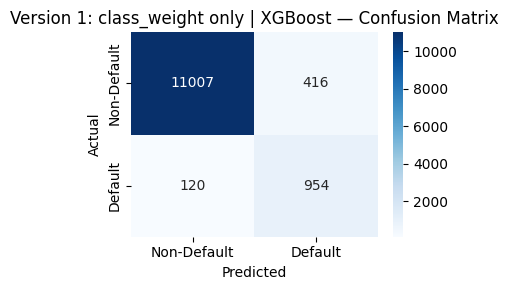


  Version 2: SMOTE

--- Logistic Regression ---
AUC-ROC : 0.9837
F2 Score: 0.8277
F1 Score: 0.7009

Classification Report:
              precision    recall  f1-score   support

 Non-Default       0.99      0.93      0.96     11423
     Default       0.56      0.94      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.78      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



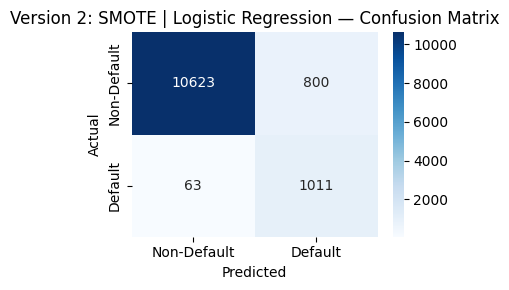


--- Random Forest ---
AUC-ROC : 0.9847
F2 Score: 0.8311
F1 Score: 0.7816

Classification Report:
              precision    recall  f1-score   support

 Non-Default       0.99      0.97      0.98     11423
     Default       0.71      0.87      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.85      0.92      0.88     12497
weighted avg       0.96      0.96      0.96     12497



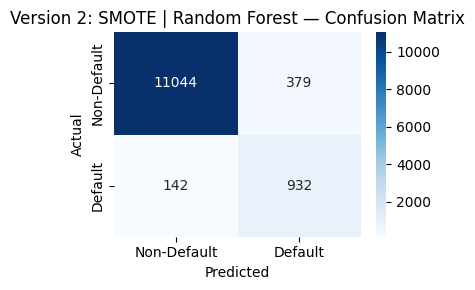


--- XGBoost ---
AUC-ROC : 0.9860
F2 Score: 0.8144
F1 Score: 0.7863

Classification Report:
              precision    recall  f1-score   support

 Non-Default       0.98      0.97      0.98     11423
     Default       0.74      0.83      0.79      1074

    accuracy                           0.96     12497
   macro avg       0.86      0.90      0.88     12497
weighted avg       0.96      0.96      0.96     12497



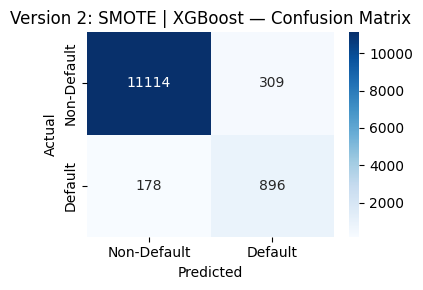

In [81]:
results_v1 = evaluate_models(models_v1, X_train_scaled,  y_train,
                              X_test_scaled, y_test, "Version 1: class_weight only")

results_v2 = evaluate_models(models_v2, X_train_smote, y_train_smote,
                              X_test_scaled, y_test, "Version 2: SMOTE")

In [82]:
rows = []
for name, res in results_v1.items():
    rows.append({'Model': name, 'Version': 'class_weight', 'AUC': res['auc'], 'F2': res['f2'], 'F1': res['f1']})
for name, res in results_v2.items():
    rows.append({'Model': name, 'Version': 'SMOTE', 'AUC': res['auc'], 'F2': res['f2'], 'F1': res['f1']})

summary = pd.DataFrame(rows).sort_values('AUC', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

              Model      Version      AUC       F2       F1
            XGBoost class_weight 0.986631 0.841864 0.780687
            XGBoost        SMOTE 0.985985 0.814397 0.786310
      Random Forest class_weight 0.985554 0.710111 0.762951
      Random Forest        SMOTE 0.984712 0.831104 0.781551
Logistic Regression        SMOTE 0.983679 0.827739 0.700867
Logistic Regression class_weight 0.983672 0.825141 0.686557


In [83]:
best_version_data = (X_train_scaled, y_train)

param_dist = {
    'n_estimators'    : [100, 200, 300, 500],
    'max_depth'       : [3, 4, 5, 6, 7],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma'           : [0, 0.1, 0.2, 0.5]
}

base_xgb = XGBClassifier(
    scale_pos_weight=10,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator           = base_xgb,
    param_distributions = param_dist,
    n_iter              = 50,
    scoring             = 'roc_auc',
    cv                  = cv,
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 1
)

search.fit(*best_version_data)

print("\nBest Parameters:", search.best_params_)
print("Best CV AUC    :", round(search.best_score_, 4))

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Parameters: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.7}
Best CV AUC    : 0.987


In [84]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'         : trial.suggest_int('max_depth', 3, 7),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'             : trial.suggest_float('gamma', 0, 0.5),
        'scale_pos_weight'  : 10,
        'use_label_encoder' : False,
        'eval_metric'       : 'logloss',
        'random_state'      : 42
    }

    model = XGBClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in cv.split(X_train_scaled, y_train):
        X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        y_prob = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, y_prob))

    return np.mean(scores)

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("\nBest Optuna Parameters:", study.best_params)
print("Best Optuna CV AUC    :", round(study.best_value, 4))

Best trial: 99. Best value: 0.987253: 100%|██████████| 100/100 [04:03<00:00,  2.44s/it]


Best Optuna Parameters: {'n_estimators': 386, 'max_depth': 3, 'learning_rate': 0.058673274831518574, 'subsample': 0.7028634269959535, 'colsample_bytree': 0.7496737629688638, 'min_child_weight': 8, 'gamma': 0.18198263974020037}
Best Optuna CV AUC    : 0.9873



  RandomizedSearchCV XGBoost
Optimal Threshold : 0.5087
AUC-ROC           : 0.9887
F2 Score          : 0.8607
F1 Score          : 0.7452

Classification Report:
              precision    recall  f1-score   support

 Non-Default       1.00      0.94      0.97     11423
     Default       0.61      0.96      0.75      1074

    accuracy                           0.94     12497
   macro avg       0.80      0.95      0.86     12497
weighted avg       0.96      0.94      0.95     12497



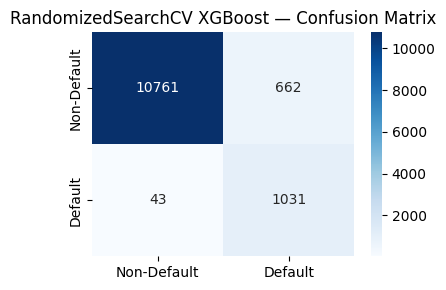

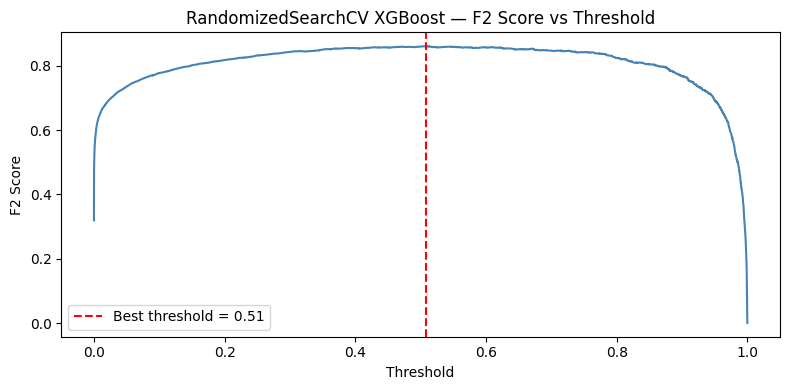

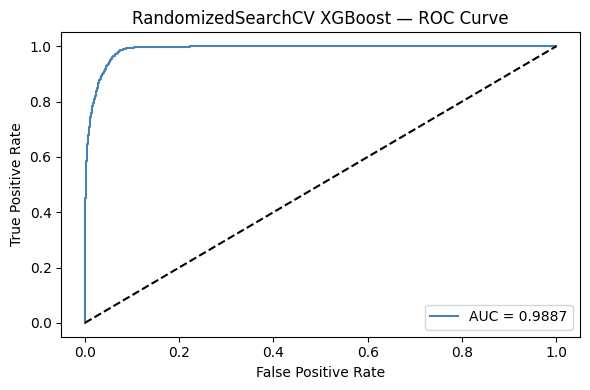


  Optuna XGBoost
Optimal Threshold : 0.5685
AUC-ROC           : 0.9887
F2 Score          : 0.8595
F1 Score          : 0.7522

Classification Report:
              precision    recall  f1-score   support

 Non-Default       1.00      0.95      0.97     11423
     Default       0.62      0.95      0.75      1074

    accuracy                           0.95     12497
   macro avg       0.81      0.95      0.86     12497
weighted avg       0.96      0.95      0.95     12497



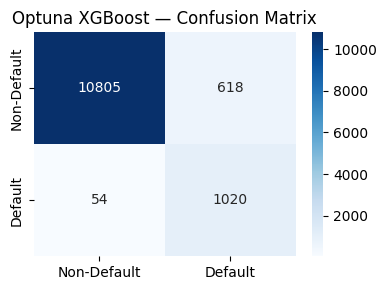

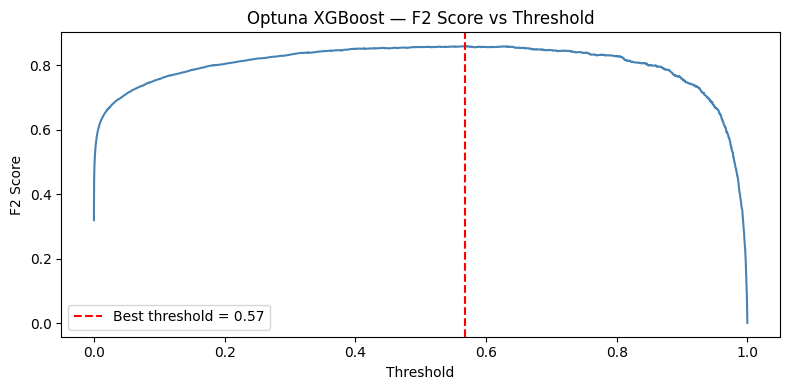

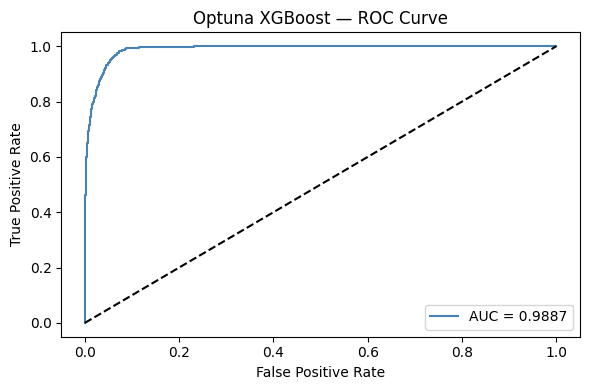


  FINAL COMPARISON
             Model  AUC-ROC  F2 Score  F1 Score  Threshold
RandomizedSearchCV 0.988675  0.860745  0.745211   0.508688
            Optuna 0.988695  0.859454  0.752212   0.568467


In [85]:
# --- Model 1: RandomizedSearchCV best model (already trained) ---
best_model_rs = search.best_estimator_

# --- Model 2: Optuna best model ---
best_model_optuna = XGBClassifier(
    **study.best_params,
    scale_pos_weight  = 10,
    use_label_encoder = False,
    eval_metric       = 'logloss',
    random_state      = 42
)
best_model_optuna.fit(X_train_scaled, y_train)

# --- Evaluation function with threshold tuning ---
def full_evaluate(model, model_name, X_test, y_test):
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")

    y_prob = model.predict_proba(X_test)[:, 1]

    # threshold tuning
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
    f2_scores = []
    for p, r in zip(precisions, recalls):
        if (p + r) == 0:
            f2_scores.append(0)
        else:
            f2_scores.append((5 * p * r) / (4 * p + r))

    best_idx       = np.argmax(f2_scores)
    best_threshold = thresholds[best_idx]
    y_pred         = (y_prob >= best_threshold).astype(int)

    auc = roc_auc_score(y_test, y_prob)
    f2  = fbeta_score(y_test, y_pred, beta=2)
    f1  = f1_score(y_test, y_pred)

    print(f"Optimal Threshold : {best_threshold:.4f}")
    print(f"AUC-ROC           : {auc:.4f}")
    print(f"F2 Score          : {f2:.4f}")
    print(f"F1 Score          : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Non-Default', 'Default']))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Default', 'Default'],
                yticklabels=['Non-Default', 'Default'])
    plt.title(f'{model_name} — Confusion Matrix')
    plt.tight_layout()
    plt.show()

    # Threshold plot
    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, f2_scores[:-1], color='steelblue')
    plt.axvline(best_threshold, color='red', linestyle='--',
                label=f'Best threshold = {best_threshold:.2f}')
    plt.xlabel('Threshold')
    plt.ylabel('F2 Score')
    plt.title(f'{model_name} — F2 Score vs Threshold')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='steelblue', label=f'AUC = {auc:.4f}')
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} — ROC Curve')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        'model'    : model,
        'auc'      : auc,
        'f2'       : f2,
        'f1'       : f1,
        'threshold': best_threshold,
        'y_prob'   : y_prob
    }

# --- Run both ---
res_rs     = full_evaluate(best_model_rs,     "RandomizedSearchCV XGBoost", X_test_scaled, y_test)
res_optuna = full_evaluate(best_model_optuna, "Optuna XGBoost",             X_test_scaled, y_test)

# --- Final comparison ---
print("\n" + "="*50)
print("  FINAL COMPARISON")
print("="*50)
comparison = pd.DataFrame({
    'Model'    : ['RandomizedSearchCV', 'Optuna'],
    'AUC-ROC'  : [res_rs['auc'],  res_optuna['auc']],
    'F2 Score' : [res_rs['f2'],   res_optuna['f2']],
    'F1 Score' : [res_rs['f1'],   res_optuna['f1']],
    'Threshold': [res_rs['threshold'], res_optuna['threshold']]
})
print(comparison.to_string(index=False))

#### optuna wins 
because it can catch more false positives than randomisedsearch , and for this project false postive and recall are more important


### MODEL EVALUATION : USING KS STATIC,RANK ORDERING AND GINI COEFF

In [86]:
res_optuna

{'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.7496737629688638, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric='logloss', feature_types=None, feature_weights=None,
               gamma=0.18198263974020037, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.058673274831518574,
               max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=3, max_leaves=None,
               min_child_weight=8, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=386, n_jobs=None,
               num_parallel_tree=None, ...),
 'auc': 0.9886946865181506,
 'f2': 0.8594539939332659,
 'f1': 0.7522123893805309,
 'threshold': np.float32(0.56846654),
 'y_prob': array([8.0658621e-01, 1.72831

In [87]:
probablities = best_model_optuna.predict_proba(X_test_scaled)[:,1]
final_df = pd.DataFrame({"default_truth":y_test,"default_prob":probablities})
final_df

,default_truth,default_prob
19205,0,0.806586
15514,0,0.000017
30367,0,0.001504
35347,0,0.001453
41814,1,0.987268
...,...,...
29297,0,0.000439
20567,0,0.002472
681,0,0.002768
33682,0,0.741935


In [88]:
final_df['deciles'] = pd.qcut(final_df['default_prob'],10,labels=False,duplicates='drop')
final_df

,default_truth,default_prob,deciles
19205,0,0.806586,9
15514,0,0.000017,1
30367,0,0.001504,5
35347,0,0.001453,5
41814,1,0.987268,9
...,...,...,...
29297,0,0.000439,4
20567,0,0.002472,5
681,0,0.002768,5
33682,0,0.741935,8


In [89]:
final_df_2 = final_df.groupby('deciles').apply(lambda x: pd.Series(
    {
    'Min_Prob' : x['default_prob'].min(),
    'Max_Prob' : x['default_prob'].max(),
    'Event' : x['default_truth'].sum(),
    'Non_Events':x['default_truth'].count() - x['default_truth'].sum(),
    }
))
final_df_2.reset_index(inplace=True)
final_df_2

,deciles,Min_Prob,Max_Prob,Event,Non_Events
0,0,6.822465e-07,0.000014,0.0,1250.0
1,1,1.439744e-05,0.000049,0.0,1250.0
2,2,4.920191e-05,0.000138,0.0,1249.0
3,3,1.385484e-04,0.000385,0.0,1250.0
4,4,3.856090e-04,0.001191,0.0,1250.0
5,5,1.192148e-03,0.004202,0.0,1249.0
6,6,4.209028e-03,0.022523,1.0,1249.0
7,7,2.255423e-02,0.153182,3.0,1246.0
8,8,1.541709e-01,0.773950,147.0,1103.0
9,9,7.742343e-01,0.999990,923.0,327.0


In [90]:
final_df_2['Event_Rate'] = final_df_2.Event*100/(final_df_2.Event+final_df_2.Non_Events)
final_df_2['Non_Event_Rate'] = (final_df_2.Non_Events * 100)/(final_df_2.Event + final_df_2.Non_Events)
final_df_2

,deciles,Min_Prob,Max_Prob,Event,Non_Events,Event_Rate,Non_Event_Rate
0,0,6.822465e-07,0.000014,0.0,1250.0,0.000000,100.000000
1,1,1.439744e-05,0.000049,0.0,1250.0,0.000000,100.000000
2,2,4.920191e-05,0.000138,0.0,1249.0,0.000000,100.000000
3,3,1.385484e-04,0.000385,0.0,1250.0,0.000000,100.000000
4,4,3.856090e-04,0.001191,0.0,1250.0,0.000000,100.000000
5,5,1.192148e-03,0.004202,0.0,1249.0,0.000000,100.000000
6,6,4.209028e-03,0.022523,1.0,1249.0,0.080000,99.920000
7,7,2.255423e-02,0.153182,3.0,1246.0,0.240192,99.759808
8,8,1.541709e-01,0.773950,147.0,1103.0,11.760000,88.240000
9,9,7.742343e-01,0.999990,923.0,327.0,73.840000,26.160000


In [91]:
final_df_2 =final_df_2.sort_values(by='deciles', ascending=False).reset_index(drop=True)
final_df_2

,deciles,Min_Prob,Max_Prob,Event,Non_Events,Event_Rate,Non_Event_Rate
0,9,7.742343e-01,0.999990,923.0,327.0,73.840000,26.160000
1,8,1.541709e-01,0.773950,147.0,1103.0,11.760000,88.240000
2,7,2.255423e-02,0.153182,3.0,1246.0,0.240192,99.759808
3,6,4.209028e-03,0.022523,1.0,1249.0,0.080000,99.920000
4,5,1.192148e-03,0.004202,0.0,1249.0,0.000000,100.000000
5,4,3.856090e-04,0.001191,0.0,1250.0,0.000000,100.000000
6,3,1.385484e-04,0.000385,0.0,1250.0,0.000000,100.000000
7,2,4.920191e-05,0.000138,0.0,1249.0,0.000000,100.000000
8,1,1.439744e-05,0.000049,0.0,1250.0,0.000000,100.000000
9,0,6.822465e-07,0.000014,0.0,1250.0,0.000000,100.000000


In [92]:
final_df_2['Cum_Event'] = final_df_2['Event'].cumsum()
final_df_2['Cum_Non_Event'] = final_df_2['Non_Events'].cumsum()
final_df_2


,deciles,Min_Prob,Max_Prob,Event,Non_Events,Event_Rate,Non_Event_Rate,Cum_Event,Cum_Non_Event
0,9,7.742343e-01,0.999990,923.0,327.0,73.840000,26.160000,923.0,327.0
1,8,1.541709e-01,0.773950,147.0,1103.0,11.760000,88.240000,1070.0,1430.0
2,7,2.255423e-02,0.153182,3.0,1246.0,0.240192,99.759808,1073.0,2676.0
3,6,4.209028e-03,0.022523,1.0,1249.0,0.080000,99.920000,1074.0,3925.0
4,5,1.192148e-03,0.004202,0.0,1249.0,0.000000,100.000000,1074.0,5174.0
5,4,3.856090e-04,0.001191,0.0,1250.0,0.000000,100.000000,1074.0,6424.0
6,3,1.385484e-04,0.000385,0.0,1250.0,0.000000,100.000000,1074.0,7674.0
7,2,4.920191e-05,0.000138,0.0,1249.0,0.000000,100.000000,1074.0,8923.0
8,1,1.439744e-05,0.000049,0.0,1250.0,0.000000,100.000000,1074.0,10173.0
9,0,6.822465e-07,0.000014,0.0,1250.0,0.000000,100.000000,1074.0,11423.0


In [93]:
final_df_2['Cum_Event_Rate'] = final_df_2['Cum_Event'] * 100/ final_df_2['Event'].sum()
final_df_2['Cum_Non_Event_Rate'] = final_df_2['Cum_Non_Event'] * 100 / final_df_2['Non_Events'].sum()
final_df_2


,deciles,Min_Prob,Max_Prob,Event,Non_Events,Event_Rate,Non_Event_Rate,Cum_Event,Cum_Non_Event,Cum_Event_Rate,Cum_Non_Event_Rate
0,9,7.742343e-01,0.999990,923.0,327.0,73.840000,26.160000,923.0,327.0,85.940410,2.862646
1,8,1.541709e-01,0.773950,147.0,1103.0,11.760000,88.240000,1070.0,1430.0,99.627561,12.518603
2,7,2.255423e-02,0.153182,3.0,1246.0,0.240192,99.759808,1073.0,2676.0,99.906890,23.426420
3,6,4.209028e-03,0.022523,1.0,1249.0,0.080000,99.920000,1074.0,3925.0,100.000000,34.360501
4,5,1.192148e-03,0.004202,0.0,1249.0,0.000000,100.000000,1074.0,5174.0,100.000000,45.294581
5,4,3.856090e-04,0.001191,0.0,1250.0,0.000000,100.000000,1074.0,6424.0,100.000000,56.237416
6,3,1.385484e-04,0.000385,0.0,1250.0,0.000000,100.000000,1074.0,7674.0,100.000000,67.180250
7,2,4.920191e-05,0.000138,0.0,1249.0,0.000000,100.000000,1074.0,8923.0,100.000000,78.114331
8,1,1.439744e-05,0.000049,0.0,1250.0,0.000000,100.000000,1074.0,10173.0,100.000000,89.057165
9,0,6.822465e-07,0.000014,0.0,1250.0,0.000000,100.000000,1074.0,11423.0,100.000000,100.000000


In [94]:
final_df_2['KS'] = abs(final_df_2['Cum_Event_Rate'] - final_df_2['Cum_Non_Event_Rate'])
final_df_2

,deciles,Min_Prob,Max_Prob,Event,Non_Events,Event_Rate,Non_Event_Rate,Cum_Event,Cum_Non_Event,Cum_Event_Rate,Cum_Non_Event_Rate,KS
0,9,7.742343e-01,0.999990,923.0,327.0,73.840000,26.160000,923.0,327.0,85.940410,2.862646,83.077764
1,8,1.541709e-01,0.773950,147.0,1103.0,11.760000,88.240000,1070.0,1430.0,99.627561,12.518603,87.108958
2,7,2.255423e-02,0.153182,3.0,1246.0,0.240192,99.759808,1073.0,2676.0,99.906890,23.426420,76.480470
3,6,4.209028e-03,0.022523,1.0,1249.0,0.080000,99.920000,1074.0,3925.0,100.000000,34.360501,65.639499
4,5,1.192148e-03,0.004202,0.0,1249.0,0.000000,100.000000,1074.0,5174.0,100.000000,45.294581,54.705419
5,4,3.856090e-04,0.001191,0.0,1250.0,0.000000,100.000000,1074.0,6424.0,100.000000,56.237416,43.762584
6,3,1.385484e-04,0.000385,0.0,1250.0,0.000000,100.000000,1074.0,7674.0,100.000000,67.180250,32.819750
7,2,4.920191e-05,0.000138,0.0,1249.0,0.000000,100.000000,1074.0,8923.0,100.000000,78.114331,21.885669
8,1,1.439744e-05,0.000049,0.0,1250.0,0.000000,100.000000,1074.0,10173.0,100.000000,89.057165,10.942835
9,0,6.822465e-07,0.000014,0.0,1250.0,0.000000,100.000000,1074.0,11423.0,100.000000,100.000000,0.000000


In [95]:
final_model = best_model_optuna

auc = roc_auc_score(y_test, final_model.predict_proba(X_test_scaled)[:, 1])
gini = 2 * auc - 1

print(f"AUC-ROC   : {auc:.4f}")
print(f"Gini Coeff: {gini:.4f}")

AUC-ROC   : 0.9887
Gini Coeff: 0.9774


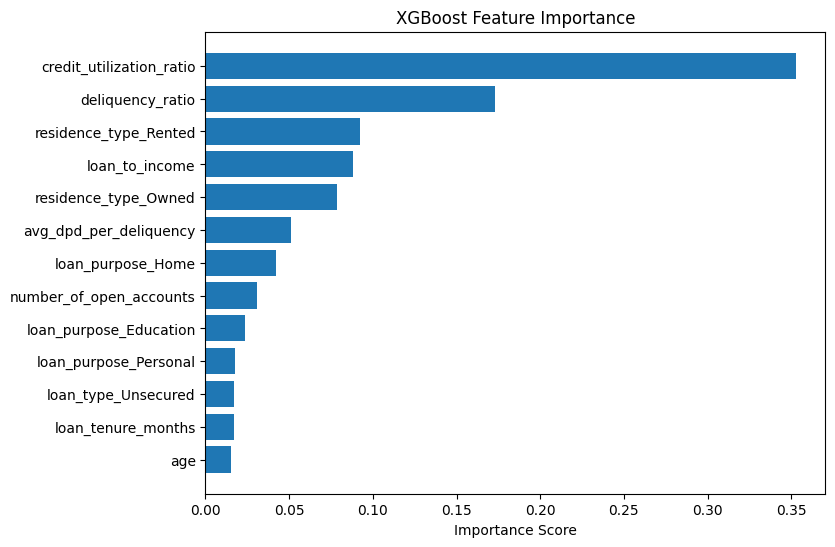

In [96]:
feature_importance = final_model.feature_importances_

coef_df = pd.DataFrame(
    feature_importance,
    index=X_train_encoded.columns,
    columns=['Importance']
)

coef_df = coef_df.sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(8,6))
plt.barh(
    coef_df.index,
    coef_df['Importance']
)

plt.xlabel("Importance Score")
plt.title("XGBoost Feature Importance")
plt.show()

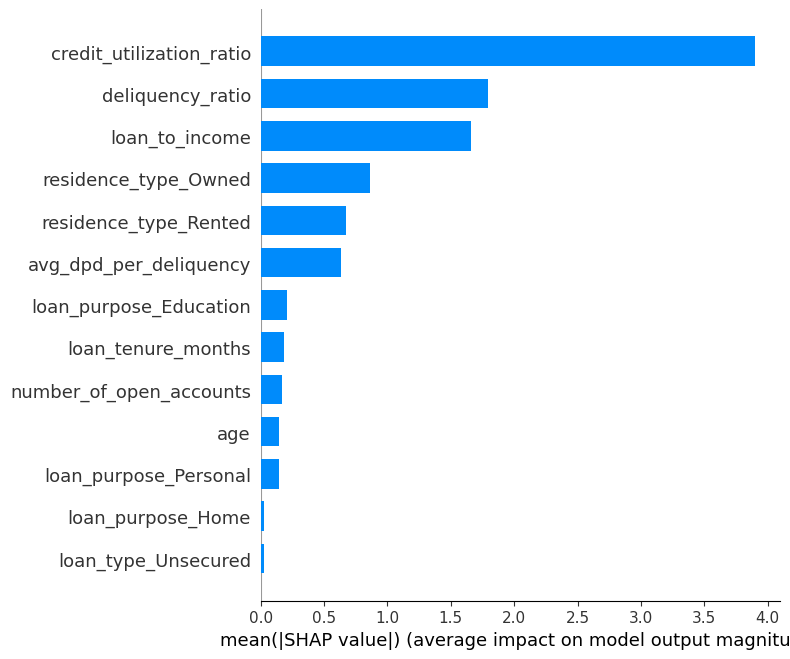

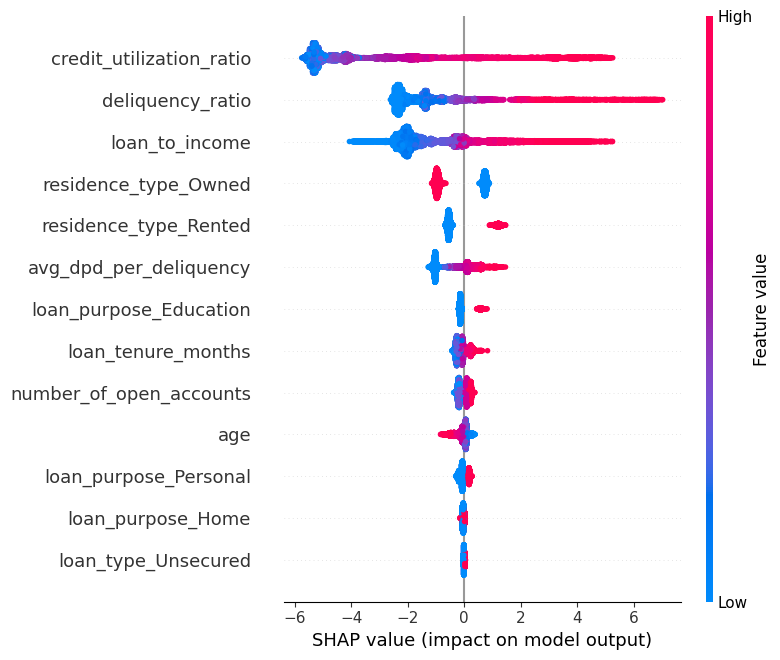

In [97]:
import shap

# use X_test_encoded column names for readable labels
feature_names = X_test_encoded.columns.tolist()

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_scaled)

# Bar plot — mean absolute SHAP per feature
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=feature_names,
                  plot_type='bar',
                  show=True)

# Beeswarm — shows direction + magnitude
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=feature_names,
                  show=True)

In [98]:
print(type(final_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [99]:
X_test_reduced

,credit_utilization_ratio,deliquency_ratio,loan_to_income,avg_dpd_per_deliquency,loan_purpose,residence_type,loan_tenure_months,loan_type,age,number_of_open_accounts
19205,98,0.00,2.65,0.00,Home,Owned,46,Secured,36,2
15514,32,0.00,1.24,0.00,Education,Owned,18,Secured,43,4
30367,82,0.00,1.07,0.00,Auto,Owned,35,Secured,30,3
35347,48,0.02,2.74,7.00,Home,Owned,46,Secured,37,4
41814,97,0.11,2.04,6.36,Home,Mortgage,44,Secured,48,3
...,...,...,...,...,...,...,...,...,...,...
29297,52,0.05,1.37,2.80,Auto,Owned,29,Secured,27,3
20567,5,0.00,3.17,0.00,Home,Rented,35,Secured,40,1
681,54,0.06,0.31,3.50,Personal,Rented,15,Unsecured,28,2
33682,85,0.00,3.65,0.00,Home,Owned,37,Secured,31,1


In [100]:
X_test_scaled

array([[ 1.85668383, -0.5972378 ,  1.12284871, ...,  0.87771841,
        -0.49826551, -0.73363592],
       [-0.38875497, -0.5972378 , -0.32527433, ...,  0.87771841,
        -0.49826551, -0.73363592],
       [ 1.31233503, -0.5972378 , -0.49987072, ...,  0.87771841,
        -0.49826551, -0.73363592],
       ...,
       [ 0.35972463, -0.25044561, -1.28041931, ..., -1.13931756,
         2.00696213,  1.36307394],
       [ 1.41440043, -0.5972378 ,  2.14988632, ...,  0.87771841,
        -0.49826551, -0.73363592],
       [ 1.61853123,  0.61653487, -0.91068577, ...,  0.87771841,
        -0.49826551,  1.36307394]], shape=(12497, 13))

In [101]:
# final
# X_train_scaled
# X_test_scaled
# y_train
# y_test
# final_model

In [102]:
X_train_encoded.columns

Index(['credit_utilization_ratio', 'deliquency_ratio', 'loan_to_income',
       'avg_dpd_per_deliquency', 'loan_tenure_months', 'age',
       'number_of_open_accounts', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Personal', 'residence_type_Owned',
       'residence_type_Rented', 'loan_type_Unsecured'],
      dtype='object')

In [103]:
from joblib import dump

model_data = {
    "model": final_model,
    "features": X_train_encoded.columns.tolist(),
    "scaler": scaler
}

dump(model_data, "Artifacts/model_data.joblib")

['Artifacts/model_data.joblib']

In [105]:
from joblib import load

obj = load("Artifacts/model_data.joblib")

print(obj.keys())
print(obj["features"])

dict_keys(['model', 'features', 'scaler'])
['credit_utilization_ratio', 'deliquency_ratio', 'loan_to_income', 'avg_dpd_per_deliquency', 'loan_tenure_months', 'age', 'number_of_open_accounts', 'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Personal', 'residence_type_Owned', 'residence_type_Rented', 'loan_type_Unsecured']


In [106]:
print(type(obj["scaler"]))

<class 'sklearn.preprocessing._data.StandardScaler'>
